In [1]:
# =============================================================================
# PAPYRUS FULL DATASET CLASSIFICATION PIPELINE
# =============================================================================
# This notebook:
# 1. Reads the full Papyrus dataset
# 2. Filters by presence of activity values (pchembl_value_Mean)
# 3. Extracts molecular features
# 4. Classifies molecules using pre-trained Random Forest
# 5. Saves data with features and predicted class
# =============================================================================

import sys
import os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import joblib
import re
import ast

# Add mol_utils to path
sys.path.insert(0, "/home/ec2-user/mol-utils/src")

from rdkit import Chem
from mol_utils import MolecularClassifier

print(f"Python: {sys.executable}")

# =============================================================================
# CONFIGURATION
# =============================================================================
PAPYRUS_FILE = "/fsx/amira/papyrus_50.5/05.5_combined_set_without_stereochemistry.tsv.xz"
MODEL_PATH = "/fsx/alex/MolecularTypeClassifier-1/scratch/molecular_classifier_model.joblib"
ENCODER_PATH = "/fsx/alex/MolecularTypeClassifier-1/scratch/molecular_classifier_label_encoder.joblib"
OUTPUT_DIR = "/fsx/amira/papyrus_50.5_results/classified_full"

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Input: {PAPYRUS_FILE}")
print(f"Output: {OUTPUT_DIR}")


Python: /home/ec2-user/MolecularTypeClassifier/.pixi/envs/default/bin/python
Input: /fsx/amira/papyrus_50.5/05.5_combined_set_without_stereochemistry.tsv.xz
Output: /fsx/amira/papyrus_50.5_results/classified_full


In [2]:
# =============================================================================
# Initialize Classifier and Load Model
# =============================================================================

classifier = MolecularClassifier()
print("MolecularClassifier initialized")

# Load pre-trained model
clf = joblib.load(MODEL_PATH)
label_encoder = joblib.load(ENCODER_PATH)
print(f"Model loaded from {MODEL_PATH}")
print(f"Classes: {label_encoder.classes_}")


MolecularClassifier initialized
Model loaded from /fsx/alex/MolecularTypeClassifier-1/scratch/molecular_classifier_model.joblib
Classes: ['can_peptide' 'sm' 'unwanted']


In [ ]:
# =============================================================================
# Feature Extraction Functions
# =============================================================================

def mol_from_smiles(smiles: str):
    """Safe RDKit SMILES to Mol conversion."""
    if not isinstance(smiles, str) or not smiles.strip():
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        try:
            mol = Chem.MolFromSmiles(smiles, sanitize=False)
            if mol is not None:
                Chem.SanitizeMol(mol)
        except Exception:
            return None
    return mol


def parse_feature_string(feature_str) -> dict:
    """Parse MolecularFeatures string to dict."""
    if not isinstance(feature_str, str) or not feature_str.strip():
        return {}
    
    s = feature_str.strip()
    if s.startswith("MolecularFeatures(") and s.endswith(")"):
        s = s[len("MolecularFeatures("):-1]
    
    pattern_dict = {}
    m = re.search(r"pattern_counts\s*=\s*(\{.*\})", s)
    if m:
        pattern_text = m.group(1)
        s = s[:m.start()].rstrip().rstrip(",").rstrip()
        try:
            pattern_dict = ast.literal_eval(pattern_text)
        except Exception:
            pattern_dict = {}
    
    features = {}
    for kv in re.split(r"\s*,\s*", s):
        if "=" not in kv:
            continue
        k, v = kv.split("=", 1)
        k = k.strip()
        v = v.strip()
        try:
            if re.fullmatch(r"[-+]?(?:\d+\.\d*|\d*\.\d+)(?:[eE][-+]?\d+)?", v):
                v = float(v)
            elif re.fullmatch(r"[-+]?\d+", v):
                v = int(v)
        except Exception:
            pass
        features[k] = v
    
    for pk, pv in pattern_dict.items():
        features[f"pattern_{pk}"] = pv
    
    return features


def extract_features_for_smiles(smiles: str) -> dict:
    """Extract features for a single SMILES using MolecularClassifier."""
    mol = mol_from_smiles(smiles)
    if mol is None:
        return {}
    
    try:
        feats = classifier.extract_features(mol)
        if isinstance(feats, dict):
            return feats
        if isinstance(feats, pd.Series):
            return feats.to_dict()
        feat_str = str(feats)
        return parse_feature_string(feat_str)
    except Exception:
        return {}


# Model feature columns (52 features)
MODEL_FEATURE_COLUMNS = [
    'molecular_weight', 'heavy_atom_count', 'ring_count', 'largest_ring_size',
    'percent_heavy_in_rings', 'rotatable_bonds', 'peptide_bond_count',
    'peptide_backbone_length', 'nucleotide_count', 'glycosidic_bond_count',
    'aromatic_ring_count', 'pattern_AA_ASPARAGINE', 'pattern_AA_ASPARTATE',
    'pattern_AA_GLUTAMATE', 'pattern_AA_GLYCINE', 'pattern_AA_ISOLEUCINE',
    'pattern_AA_LEUCINE', 'pattern_AA_PHENYLALANINE', 'pattern_AA_PROLINE',
    'pattern_AA_TYROSINE', 'pattern_ALPHA_AMINO_ACID', 'pattern_BETA_AMINO_ACID',
    'pattern_PEPTIDE_BACKBONE', 'x', 'pattern_AA_HISTIDINE',
    'pattern_AA_SERINE', 'pattern_AA_TRYPTOPHAN', 'pattern_AA_ALANINE',
    'pattern_AA_VALINE', 'pattern_AA_CYSTEINE', 'pattern_AA_GLUTAMINE',
    'pattern_DISULFIDE', 'pattern_MACROCYCLE_12', 'pattern_MACROCYCLE_15',
    'pattern_N_METHYL_PEPTIDE', 'pattern_PHOSPHATE_BACKBONE', 'pattern_FURANOSE',
    'pattern_PYRIMIDINE_BASE', 'pattern_NUCLEOBASE_ADENINE', 'pattern_AA_LYSINE',
    'pattern_AA_METHIONINE', 'pattern_AA_THREONINE', 'pattern_GLYCOSIDIC_BOND',
    'pattern_PYRANOSE', 'pattern_NUCLEOBASE_URACIL', 'pattern_GALACTOSE',
    'pattern_GLUCOSE', 'pattern_MANNOSE', 'pattern_NUCLEOBASE_GUANINE',
    'pattern_NUCLEOBASE_THYMINE', 'pattern_NUCLEOBASE_CYTOSINE', 'pattern_DEOXYRIBOSE'
]

print(f"Feature extraction functions defined.")
print(f"Model expects {len(MODEL_FEATURE_COLUMNS)} features.")


Feature extraction functions defined.
Model expects 52 features.


In [4]:
# =============================================================================
# STEP 1: Read and Filter Papyrus Dataset
# =============================================================================

print("=" * 80)
print("STEP 1: Reading and filtering Papyrus dataset")
print("=" * 80)
print(f"\nReading from: {PAPYRUS_FILE}")
print("Filtering for records with activity values (pchembl_value_Mean not null)")
print("This may take several minutes...\n")

chunks = []
chunk_size = 500_000
total_rows = 0
total_with_activity = 0

for i, chunk in enumerate(pd.read_csv(
    PAPYRUS_FILE, 
    sep='\t', 
    compression='xz',
    chunksize=chunk_size,
    low_memory=False
)):
    total_rows += len(chunk)
    
    # Filter for records with activity values
    filtered = chunk[chunk['pchembl_value_Mean'].notna()].copy()
    
    if len(filtered) > 0:
        chunks.append(filtered)
        total_with_activity += len(filtered)
    
    print(f"  Chunk {i+1}: {total_rows:,} rows processed, {len(filtered):,} with activity (total: {total_with_activity:,})")

# Combine filtered chunks
papyrus_df = pd.concat(chunks, ignore_index=True)

print(f"\n" + "=" * 80)
print(f"FILTERING COMPLETE")
print(f"  Total rows in Papyrus: {total_rows:,}")
print(f"  Rows with activity: {len(papyrus_df):,} ({len(papyrus_df)/total_rows*100:.2f}%)")
print(f"  Unique SMILES: {papyrus_df['SMILES'].nunique():,}")
print(f"  Unique targets: {papyrus_df['accession'].nunique()}")
print(f"  pChEMBL range: {papyrus_df['pchembl_value_Mean'].min():.2f} - {papyrus_df['pchembl_value_Mean'].max():.2f}")
print("=" * 80)


STEP 1: Reading and filtering Papyrus dataset

Reading from: /fsx/amira/papyrus_50.5/05.5_combined_set_without_stereochemistry.tsv.xz
Filtering for records with activity values (pchembl_value_Mean not null)
This may take several minutes...

  Chunk 1: 500,000 rows processed, 500,000 with activity (total: 500,000)
  Chunk 2: 1,000,000 rows processed, 500,000 with activity (total: 1,000,000)
  Chunk 3: 1,500,000 rows processed, 500,000 with activity (total: 1,500,000)
  Chunk 4: 2,000,000 rows processed, 500,000 with activity (total: 2,000,000)
  Chunk 5: 2,500,000 rows processed, 500,000 with activity (total: 2,500,000)
  Chunk 6: 3,000,000 rows processed, 451,576 with activity (total: 2,951,576)
  Chunk 7: 3,500,000 rows processed, 0 with activity (total: 2,951,576)
  Chunk 8: 4,000,000 rows processed, 0 with activity (total: 2,951,576)
  Chunk 9: 4,500,000 rows processed, 0 with activity (total: 2,951,576)
  Chunk 10: 5,000,000 rows processed, 0 with activity (total: 2,951,576)
  Chun

In [5]:
# =============================================================================
# STEP 2: Extract Features for Unique SMILES (PARALLELIZED)
# =============================================================================

from multiprocessing import Pool, cpu_count
import time

print("=" * 80)
print("STEP 2: Extracting molecular features (PARALLEL)")
print("=" * 80)

# Get unique SMILES
unique_smiles = papyrus_df['SMILES'].dropna().unique()
n_smiles = len(unique_smiles)

# Parallelization settings
N_WORKERS = min(cpu_count() - 1, 32)  # Leave 1 CPU free, max 32
CHUNK_SIZE = 1000  # Process in chunks for better progress tracking

print(f"\nExtracting features for {n_smiles:,} unique SMILES...")
print(f"Using {N_WORKERS} parallel workers")
print(f"Estimated time: {n_smiles / 500 / 60 / N_WORKERS:.0f}-{n_smiles / 300 / 60 / N_WORKERS:.0f} minutes\n")

start_time = time.time()

# Parallel feature extraction
with Pool(N_WORKERS) as pool:
    features_list = list(tqdm(
        pool.imap(extract_features_for_smiles, unique_smiles, chunksize=CHUNK_SIZE),
        total=n_smiles,
        desc=f"Extracting features ({N_WORKERS} workers)"
    ))

elapsed = time.time() - start_time

features_df = pd.DataFrame(features_list)
features_df['SMILES'] = unique_smiles

print(f"\nFeatures extracted: {features_df.shape[1] - 1} columns")
print(f"Time elapsed: {elapsed/60:.1f} minutes ({elapsed/n_smiles*1000:.2f} ms/SMILES)")
print(f"Throughput: {n_smiles/elapsed:.0f} SMILES/second")


STEP 2: Extracting molecular features (PARALLEL)

Extracting features for 1,060,667 unique SMILES...
Using 31 parallel workers
Estimated time: 1-2 minutes



Extracting features (31 workers):   0%|          | 0/1060667 [00:00<?, ?it/s]

[00:59:08] Explicit valence for atom # 12 P, 7, is greater than permitted
[00:59:08] Explicit valence for atom # 12 P, 7, is greater than permitted
[00:59:10] Explicit valence for atom # 1 P, 7, is greater than permitted
[00:59:10] Explicit valence for atom # 1 P, 7, is greater than permitted
[00:59:12] Explicit valence for atom # 31 P, 7, is greater than permitted
[00:59:12] Explicit valence for atom # 31 P, 7, is greater than permitted
[00:59:13] Explicit valence for atom # 1 C, 5, is greater than permitted
[00:59:13] Explicit valence for atom # 1 C, 5, is greater than permitted
[00:59:14] Explicit valence for atom # 24 P, 7, is greater than permitted
[00:59:14] Explicit valence for atom # 24 P, 7, is greater than permitted



Features extracted: 52 columns
Time elapsed: 0.4 minutes (0.02 ms/SMILES)
Throughput: 44926 SMILES/second


In [6]:
# =============================================================================
# STEP 3: Classify Molecules
# =============================================================================

print("=" * 80)
print("STEP 3: Classifying molecules")
print("=" * 80)

# Prepare feature matrix
X = features_df.drop(columns=['SMILES']).reindex(columns=MODEL_FEATURE_COLUMNS, fill_value=0).values
X = np.nan_to_num(X, nan=0.0).astype(np.float32)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Classifying {len(unique_smiles):,} unique molecules...")

# Predict
predictions = clf.predict(X)
pred_labels = label_encoder.inverse_transform(predictions)

# Create SMILES to prediction mapping
smiles_to_pred = dict(zip(unique_smiles, pred_labels))

# Map to full dataframe
papyrus_df['predicted_mol_class'] = papyrus_df['SMILES'].map(smiles_to_pred)

print(f"\nClassification complete!")
print(f"\nClass distribution:")
print(papyrus_df['predicted_mol_class'].value_counts())


STEP 3: Classifying molecules

Feature matrix shape: (1060667, 52)
Classifying 1,060,667 unique molecules...

Classification complete!

Class distribution:
predicted_mol_class
sm             2928719
can_peptide      15707
unwanted          7150
Name: count, dtype: int64


In [7]:
# =============================================================================
# STEP 4: Rank Targets by Peptide Binders
# =============================================================================

print("=" * 80)
print("STEP 4: Ranking targets by number of peptide binders")
print("=" * 80)

# Group by target and count molecules by class
target_class_counts = papyrus_df.groupby(['accession', 'predicted_mol_class']).agg({
    'SMILES': 'nunique',
    'pchembl_value_Mean': ['mean', 'count']
}).reset_index()
target_class_counts.columns = ['accession', 'mol_class', 'unique_smiles', 'mean_pchembl', 'n_records']

# Pivot to get counts per class for each target
target_pivot = target_class_counts.pivot(
    index='accession', 
    columns='mol_class', 
    values='unique_smiles'
).fillna(0).astype(int)

# Ensure all classes exist
for cls in ['can_peptide', 'sm', 'unwanted']:
    if cls not in target_pivot.columns:
        target_pivot[cls] = 0

# Calculate totals and percentages
target_pivot['total_molecules'] = target_pivot.sum(axis=1)
target_pivot['peptide_percent'] = (target_pivot['can_peptide'] / target_pivot['total_molecules'] * 100).round(2)
target_pivot['sm_percent'] = (target_pivot['sm'] / target_pivot['total_molecules'] * 100).round(2)

# Rank by number of peptide binders (descending)
target_ranking = target_pivot.sort_values('can_peptide', ascending=False).reset_index()
target_ranking['rank'] = range(1, len(target_ranking) + 1)

# Reorder columns
target_ranking = target_ranking[['rank', 'accession', 'can_peptide', 'sm', 'unwanted', 
                                  'total_molecules', 'peptide_percent', 'sm_percent']]

print(f"\n{'='*100}")
print(f"TOP 50 TARGETS BY PEPTIDE BINDER COUNT")
print(f"{'='*100}")
print(f"\n{'Rank':<6} {'Target':<15} {'Peptides':<12} {'SMs':<12} {'Unwanted':<12} {'Total':<12} {'%Peptide':<10}")
print("-" * 100)

for _, row in target_ranking.head(50).iterrows():
    print(f"{row['rank']:<6} {row['accession']:<15} {row['can_peptide']:<12} {row['sm']:<12} "
          f"{row['unwanted']:<12} {row['total_molecules']:<12} {row['peptide_percent']:<10.1f}%")

print(f"\n{'='*100}")
print(f"SUMMARY STATISTICS")
print(f"{'='*100}")
print(f"\nTotal targets: {len(target_ranking):,}")
print(f"Targets with peptide binders: {(target_ranking['can_peptide'] > 0).sum():,}")
print(f"Targets with >10 peptide binders: {(target_ranking['can_peptide'] > 10).sum():,}")
print(f"Targets with >100 peptide binders: {(target_ranking['can_peptide'] > 100).sum():,}")
print(f"\nTop 10 peptide-rich targets account for {target_ranking.head(10)['can_peptide'].sum():,} peptide binders")

# Save ranking to file
output_ranking = f"{OUTPUT_DIR}/target_peptide_ranking.csv"
target_ranking.to_csv(output_ranking, index=False)
print(f"\nSaved target ranking to {output_ranking}")


STEP 4: Ranking targets by number of peptide binders

TOP 50 TARGETS BY PEPTIDE BINDER COUNT

Rank   Target          Peptides     SMs          Unwanted     Total        %Peptide  
----------------------------------------------------------------------------------------------------
1      P00352          315          74789        31           75135        0.4       %
2      P16473          233          16055        1            16289        1.4       %
3      P27487          191          3957         9            4157         4.6       %
4      P51450          170          63514        8            63692        0.3       %
5      P02545          167          35669        8            35844        0.5       %
6      P00811          166          61520        48           61734        0.3       %
7      Q9NUW8          159          32125        12           32296        0.5       %
8      P00918          157          6273         0            6430         2.4       %
9      P00915          

In [8]:
# =============================================================================
# STEP 4a: Analyze Peptide Content in TOP 100 SMALL MOLECULE-RICH Targets
# =============================================================================

print("=" * 80)
print("STEP 4a: Peptide content in TOP 100 targets by SMALL MOLECULE count")
print("=" * 80)

# Rank targets by number of SMALL MOLECULES (descending)
sm_ranking = target_pivot.sort_values('sm', ascending=False).reset_index()
sm_ranking['rank'] = range(1, len(sm_ranking) + 1)
sm_ranking = sm_ranking[['rank', 'accession', 'sm', 'can_peptide', 'unwanted', 
                         'total_molecules', 'peptide_percent', 'sm_percent']]

print(f"\n{'='*110}")
print(f"TOP 100 TARGETS BY SMALL MOLECULE COUNT (showing peptide content)")
print(f"{'='*110}")
print(f"\n{'Rank':<6} {'Target':<15} {'SMs':<12} {'Peptides':<12} {'Unwanted':<12} {'Total':<12} {'%Peptide':<10} {'%SM':<10}")
print("-" * 110)

for _, row in sm_ranking.head(100).iterrows():
    print(f"{row['rank']:<6} {row['accession']:<15} {row['sm']:<12} {row['can_peptide']:<12} "
          f"{row['unwanted']:<12} {row['total_molecules']:<12} {row['peptide_percent']:<10.1f}% {row['sm_percent']:<10.1f}%")

# Summary statistics for top 100 SM-rich targets
top100_sm = sm_ranking.head(100)
print(f"\n{'='*80}")
print("SUMMARY: Top 100 SM-rich targets")
print(f"{'='*80}")
print(f"\nTotal small molecules in top 100: {top100_sm['sm'].sum():,}")
print(f"Total peptides in top 100: {top100_sm['can_peptide'].sum():,}")
print(f"Total unwanted in top 100: {top100_sm['unwanted'].sum():,}")
print(f"\nMean peptide % across top 100: {top100_sm['peptide_percent'].mean():.2f}%")
print(f"Median peptide % across top 100: {top100_sm['peptide_percent'].median():.2f}%")
print(f"Min peptide %: {top100_sm['peptide_percent'].min():.2f}%")
print(f"Max peptide %: {top100_sm['peptide_percent'].max():.2f}%")
print(f"\nTargets with >0 peptides: {(top100_sm['can_peptide'] > 0).sum()}")
print(f"Targets with >10 peptides: {(top100_sm['can_peptide'] > 10).sum()}")
print(f"Targets with >100 peptides: {(top100_sm['can_peptide'] > 100).sum()}")
print(f"Targets with >5% peptide: {(top100_sm['peptide_percent'] > 5).sum()}")
print(f"Targets with >10% peptide: {(top100_sm['peptide_percent'] > 10).sum()}")

# Save SM-ranking
output_sm_ranking = f"{OUTPUT_DIR}/target_sm_ranking_top100.tsv"
sm_ranking.head(100).to_csv(output_sm_ranking, sep='\t', index=False)
print(f"\nSaved SM ranking to {output_sm_ranking}")


STEP 4a: Peptide content in TOP 100 targets by SMALL MOLECULE count

TOP 100 TARGETS BY SMALL MOLECULE COUNT (showing peptide content)

Rank   Target          SMs          Peptides     Unwanted     Total        %Peptide   %SM       
--------------------------------------------------------------------------------------------------------------
1      P00352          74789        315          31           75135        0.4       % 99.5      %
2      P10636          66130        105          21           66256        0.2       % 99.8      %
3      P51450          63514        170          8            63692        0.3       % 99.7      %
4      P00811          61520        166          48           61734        0.3       % 99.7      %
5      Q03164          55204        141          27           55372        0.2       % 99.7      %
6      O00255          43703        116          29           43848        0.3       % 99.7      %
7      P02791          42101        66           8            

STEP 4a (cont): Molecular Weight Distribution - SM vs Peptides

Small Molecules: n=1,051,507, mean MW=414.3, median=401.4
Peptides: n=5,808, mean MW=285.1, median=233.3


/tmp/ipykernel_2439236/3033535598.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_box, labels=['Small Molecules', 'Peptides'], patch_artist=True)


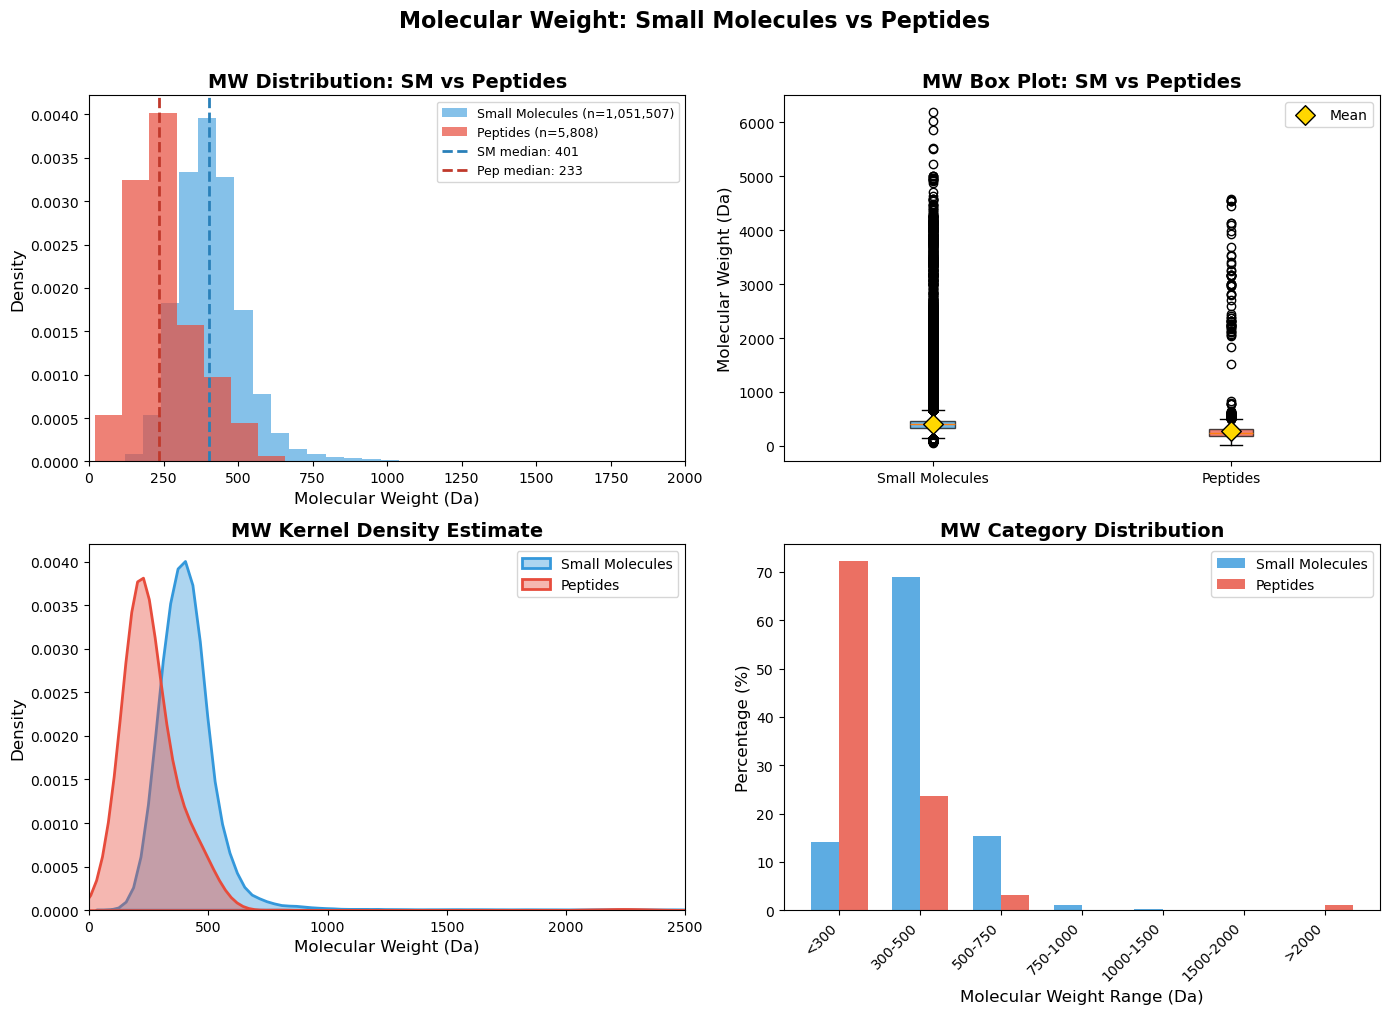


Saved plot to /fsx/amira/papyrus_50.5_results/classified_full/mw_sm_vs_peptides.png


In [10]:
# =============================================================================
# STEP 4a (cont): MW Distribution - Small Molecules vs Peptides
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("STEP 4a (cont): Molecular Weight Distribution - SM vs Peptides")
print("=" * 80)

# Get MW data for classified molecules
sm_mw = features_df[features_df['SMILES'].isin(
    papyrus_df[papyrus_df['predicted_mol_class'] == 'sm']['SMILES']
)]['molecular_weight'].dropna()

pep_mw = features_df[features_df['SMILES'].isin(
    papyrus_df[papyrus_df['predicted_mol_class'] == 'can_peptide']['SMILES']
)]['molecular_weight'].dropna()

print(f"\nSmall Molecules: n={len(sm_mw):,}, mean MW={sm_mw.mean():.1f}, median={sm_mw.median():.1f}")
print(f"Peptides: n={len(pep_mw):,}, mean MW={pep_mw.mean():.1f}, median={pep_mw.median():.1f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ===================
# TOP LEFT: Histogram comparison
# ===================
ax1 = axes[0, 0]
ax1.hist(sm_mw, bins=100, alpha=0.6, label=f'Small Molecules (n={len(sm_mw):,})', 
         color='#3498db', density=True, edgecolor='none')
ax1.hist(pep_mw, bins=50, alpha=0.7, label=f'Peptides (n={len(pep_mw):,})', 
         color='#e74c3c', density=True, edgecolor='none')
ax1.axvline(sm_mw.median(), color='#2980b9', linestyle='--', linewidth=2, label=f'SM median: {sm_mw.median():.0f}')
ax1.axvline(pep_mw.median(), color='#c0392b', linestyle='--', linewidth=2, label=f'Pep median: {pep_mw.median():.0f}')
ax1.set_xlabel('Molecular Weight (Da)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('MW Distribution: SM vs Peptides', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.set_xlim(0, 2000)

# ===================
# TOP RIGHT: Box plot comparison
# ===================
ax2 = axes[0, 1]
data_box = [sm_mw.values, pep_mw.values]
bp = ax2.boxplot(data_box, labels=['Small Molecules', 'Peptides'], patch_artist=True)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#e74c3c')
for box in bp['boxes']:
    box.set_alpha(0.7)
ax2.set_ylabel('Molecular Weight (Da)', fontsize=12)
ax2.set_title('MW Box Plot: SM vs Peptides', fontsize=14, fontweight='bold')

# Add mean markers
means = [sm_mw.mean(), pep_mw.mean()]
ax2.scatter([1, 2], means, marker='D', color='gold', s=100, zorder=5, label='Mean', edgecolors='black')
ax2.legend(loc='upper right')

# ===================
# BOTTOM LEFT: KDE plot
# ===================
ax3 = axes[1, 0]
sns.kdeplot(data=sm_mw, ax=ax3, color='#3498db', fill=True, alpha=0.4, label='Small Molecules', linewidth=2)
sns.kdeplot(data=pep_mw, ax=ax3, color='#e74c3c', fill=True, alpha=0.4, label='Peptides', linewidth=2)
ax3.set_xlabel('Molecular Weight (Da)', fontsize=12)
ax3.set_ylabel('Density', fontsize=12)
ax3.set_title('MW Kernel Density Estimate', fontsize=14, fontweight='bold')
ax3.legend(loc='upper right')
ax3.set_xlim(0, 2500)

# ===================
# BOTTOM RIGHT: MW category bar chart
# ===================
ax4 = axes[1, 1]
mw_bins = [0, 300, 500, 750, 1000, 1500, 2000, float('inf')]
mw_labels = ['<300', '300-500', '500-750', '750-1000', '1000-1500', '1500-2000', '>2000']

sm_cats = pd.cut(sm_mw, bins=mw_bins, labels=mw_labels).value_counts().sort_index()
pep_cats = pd.cut(pep_mw, bins=mw_bins, labels=mw_labels).value_counts().sort_index()

# Normalize to percentages
sm_pct = sm_cats / len(sm_mw) * 100
pep_pct = pep_cats / len(pep_mw) * 100

x = np.arange(len(mw_labels))
width = 0.35
bars1 = ax4.bar(x - width/2, sm_pct.values, width, label='Small Molecules', color='#3498db', alpha=0.8)
bars2 = ax4.bar(x + width/2, pep_pct.values, width, label='Peptides', color='#e74c3c', alpha=0.8)

ax4.set_xlabel('Molecular Weight Range (Da)', fontsize=12)
ax4.set_ylabel('Percentage (%)', fontsize=12)
ax4.set_title('MW Category Distribution', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(mw_labels, rotation=45, ha='right')
ax4.legend(loc='upper right')

plt.suptitle('Molecular Weight: Small Molecules vs Peptides', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/mw_sm_vs_peptides.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved plot to {OUTPUT_DIR}/mw_sm_vs_peptides.png")


In [11]:
# =============================================================================
# STEP 4d: MW vs Peptide Features in ALL Small Molecules
# =============================================================================

print("=" * 80)
print("STEP 4d: MW vs Peptide bond count & backbone length in ALL Small Molecules")
print("=" * 80)

# Get ALL unique SMILES classified as small molecules
all_sm_smiles = papyrus_df[papyrus_df['predicted_mol_class'] == 'sm']['SMILES'].unique()
print(f"\nTotal unique small molecule SMILES: {len(all_sm_smiles):,}")

# Get features for ALL small molecules
all_sm_features = features_df[features_df['SMILES'].isin(all_sm_smiles)].copy()

# Check if the columns exist
pep_bond_col = 'peptide_bond_count' if 'peptide_bond_count' in all_sm_features.columns else 'pattern_PEPTIDE_BOND'
pep_backbone_col = 'peptide_backbone_length' if 'peptide_backbone_length' in all_sm_features.columns else 'pattern_PEPTIDE_BACKBONE'
mw_col = 'molecular_weight'

print(f"Using columns: {mw_col}, {pep_bond_col}, {pep_backbone_col}")
print(f"\nSummary statistics for ALL small molecules (n={len(all_sm_features):,}):")

# Get clean data
mw = all_sm_features[mw_col].fillna(0)
pbc = all_sm_features[pep_bond_col].fillna(0)
pbl = all_sm_features[pep_backbone_col].fillna(0)

print(f"\n  Molecular Weight:")
print(f"    Mean: {mw.mean():.1f} Da")
print(f"    Median: {mw.median():.1f} Da")
print(f"    Range: {mw.min():.1f} - {mw.max():.1f} Da")

print(f"\n  Peptide Bond Count:")
print(f"    Mean: {pbc.mean():.3f}")
print(f"    Max: {pbc.max():.0f}")
print(f"    SMs with >=1 peptide bond: {(pbc >= 1).sum():,} ({(pbc >= 1).sum()/len(pbc)*100:.2f}%)")

print(f"\n  Peptide Backbone Length:")
print(f"    Mean: {pbl.mean():.3f}")
print(f"    Max: {pbl.max():.0f}")
print(f"    SMs with backbone >=1: {(pbl >= 1).sum():,} ({(pbl >= 1).sum()/len(pbl)*100:.2f}%)")


STEP 4d: MW vs Peptide bond count & backbone length in ALL Small Molecules

Total unique small molecule SMILES: 1,051,507
Using columns: molecular_weight, peptide_bond_count, peptide_backbone_length

Summary statistics for ALL small molecules (n=1,051,507):

  Molecular Weight:
    Mean: 414.3 Da
    Median: 401.4 Da
    Range: 58.1 - 6190.8 Da

  Peptide Bond Count:
    Mean: 0.410
    Max: 49
    SMs with >=1 peptide bond: 298,389 (28.38%)

  Peptide Backbone Length:
    Mean: 0.121
    Max: 44
    SMs with backbone >=1: 69,302 (6.59%)


/tmp/ipykernel_2439236/2717678810.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(data_by_cat, labels=['0', '1', '2', '3', '4+'], patch_artist=True)
/tmp/ipykernel_2439236/2717678810.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax4.boxplot(data_by_cat_pbl, labels=['0', '1', '2', '3', '4+'], patch_artist=True)


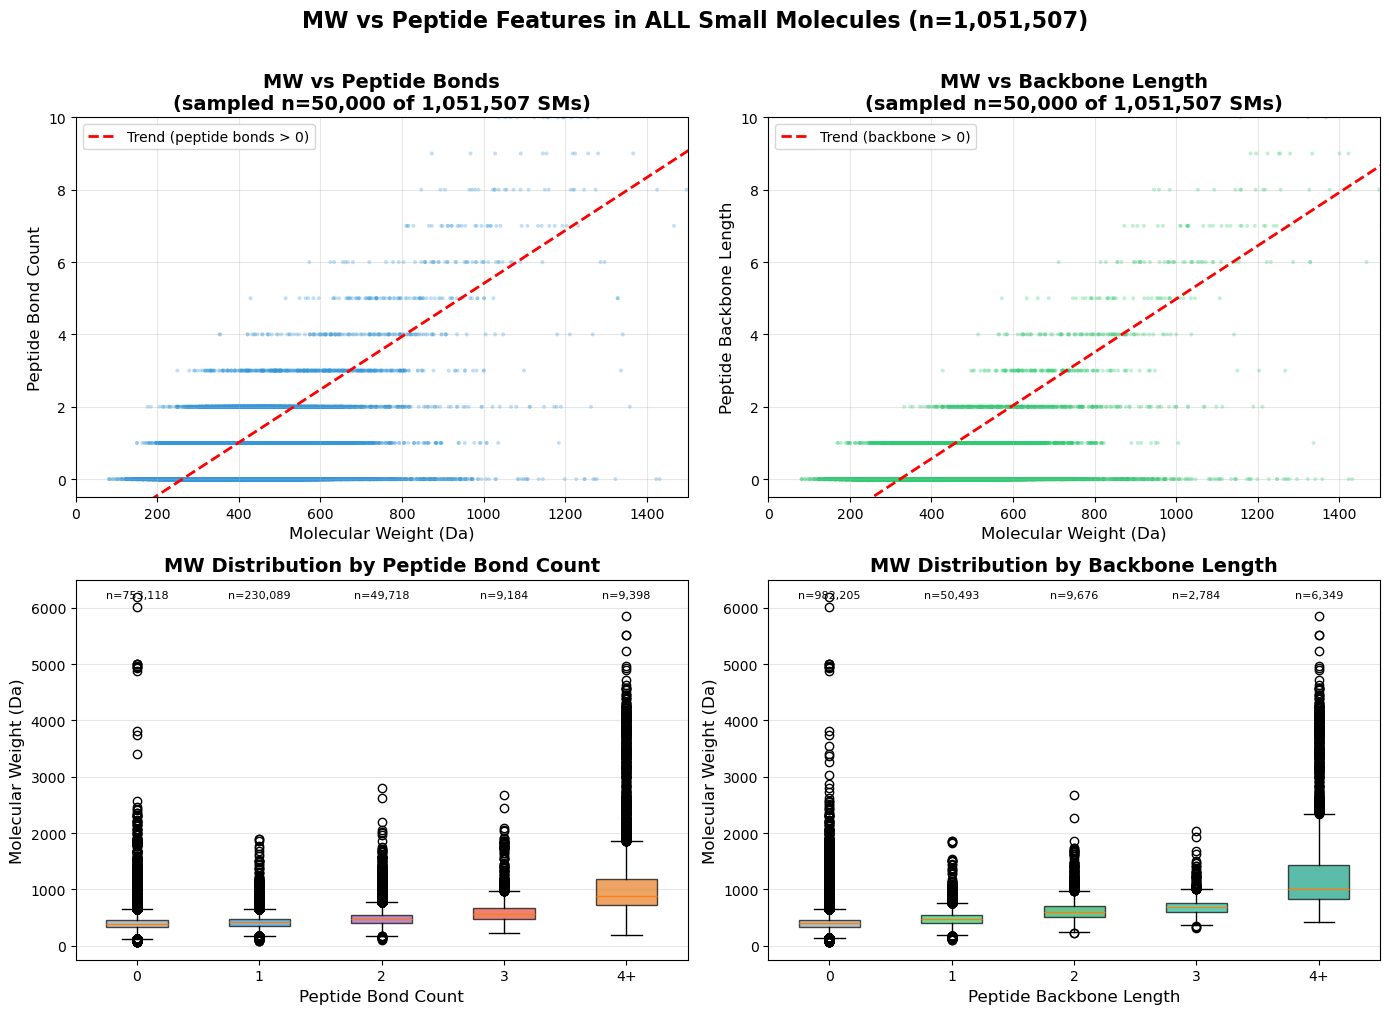


Saved plot to /fsx/amira/papyrus_50.5_results/classified_full/mw_vs_peptide_features_all_sm.png


In [13]:
# =============================================================================
# STEP 4d (cont): MW vs Peptide Features in ALL Small Molecules
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Use data from previous cell
n_total = len(all_sm_features)
n_with_pep_bond = (pbc > 0).sum()
n_with_backbone = (pbl > 0).sum()

# ===================
# TOP LEFT: MW vs Peptide Bond Count (scatter with density)
# ===================
ax1 = axes[0, 0]
# Sample for performance if needed
sample_size = min(50000, len(all_sm_features))
sample_idx = np.random.choice(len(all_sm_features), sample_size, replace=False)
mw_sample = mw.iloc[sample_idx]
pbc_sample = pbc.iloc[sample_idx]

scatter1 = ax1.scatter(mw_sample, pbc_sample, c='#3498db', alpha=0.3, s=8, edgecolors='none', rasterized=True)
ax1.set_xlabel('Molecular Weight (Da)', fontsize=12)
ax1.set_ylabel('Peptide Bond Count', fontsize=12)
ax1.set_title(f'MW vs Peptide Bonds\n(sampled n={sample_size:,} of {n_total:,} SMs)', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1500)
ax1.set_ylim(-0.5, max(10, pbc.quantile(0.99) + 1))
ax1.grid(True, alpha=0.3)

# Add trend line for molecules with peptide bonds
mask_pbc = pbc_sample > 0
if mask_pbc.sum() > 10:
    z = np.polyfit(mw_sample[mask_pbc], pbc_sample[mask_pbc], 1)
    p = np.poly1d(z)
    x_line = np.linspace(mw_sample[mask_pbc].min(), mw_sample[mask_pbc].max(), 100)
    ax1.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend (peptide bonds > 0)')
    ax1.legend(loc='upper left')
# ===================
# TOP RIGHT: MW vs Peptide Backbone Length (scatter)
# ===================
ax2 = axes[0, 1]
pbl_sample = pbl.iloc[sample_idx]

scatter2 = ax2.scatter(mw_sample, pbl_sample, c='#2ecc71', alpha=0.3, s=8, edgecolors='none', rasterized=True)
ax2.set_xlabel('Molecular Weight (Da)', fontsize=12)
ax2.set_ylabel('Peptide Backbone Length', fontsize=12)
ax2.set_title(f'MW vs Backbone Length\n(sampled n={sample_size:,} of {n_total:,} SMs)', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 1500)
ax2.set_ylim(-0.5, max(10, pbl.quantile(0.99) + 1))
ax2.grid(True, alpha=0.3)

# Add trend line for molecules with backbone
mask_pbl = pbl_sample > 0
if mask_pbl.sum() > 10:
    z = np.polyfit(mw_sample[mask_pbl], pbl_sample[mask_pbl], 1)
    p = np.poly1d(z)
    x_line = np.linspace(mw_sample[mask_pbl].min(), mw_sample[mask_pbl].max(), 100)
    ax2.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend (backbone > 0)')
    ax2.legend(loc='upper left')

# ===================
# BOTTOM LEFT: Box plot - MW by Peptide Bond Count category
# ===================
ax3 = axes[1, 0]
pbc_cats = pd.cut(pbc, bins=[-1, 0, 1, 2, 3, 100], labels=['0', '1', '2', '3', '4+'])
data_by_cat = [mw[pbc_cats == cat].values for cat in ['0', '1', '2', '3', '4+']]

bp = ax3.boxplot(data_by_cat, labels=['0', '1', '2', '3', '4+'], patch_artist=True)
colors_box = ['#95a5a6', '#3498db', '#9b59b6', '#e74c3c', '#e67e22']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.set_xlabel('Peptide Bond Count', fontsize=12)
ax3.set_ylabel('Molecular Weight (Da)', fontsize=12)
ax3.set_title('MW Distribution by Peptide Bond Count', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Add count annotations
for i, cat in enumerate(['0', '1', '2', '3', '4+']):
    n = (pbc_cats == cat).sum()
    ax3.text(i+1, ax3.get_ylim()[1]*0.95, f'n={n:,}', ha='center', fontsize=8, rotation=0)

# ===================
# BOTTOM RIGHT: Box plot - MW by Backbone Length category
# ===================
ax4 = axes[1, 1]
pbl_cats = pd.cut(pbl, bins=[-1, 0, 1, 2, 3, 100], labels=['0', '1', '2', '3', '4+'])
data_by_cat_pbl = [mw[pbl_cats == cat].values for cat in ['0', '1', '2', '3', '4+']]

bp2 = ax4.boxplot(data_by_cat_pbl, labels=['0', '1', '2', '3', '4+'], patch_artist=True)
colors_box2 = ['#95a5a6', '#2ecc71', '#27ae60', '#1abc9c', '#16a085']
for patch, color in zip(bp2['boxes'], colors_box2):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax4.set_xlabel('Peptide Backbone Length', fontsize=12)
ax4.set_ylabel('Molecular Weight (Da)', fontsize=12)
ax4.set_title('MW Distribution by Backbone Length', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# Add count annotations
for i, cat in enumerate(['0', '1', '2', '3', '4+']):
    n = (pbl_cats == cat).sum()
    ax4.text(i+1, ax4.get_ylim()[1]*0.95, f'n={n:,}', ha='center', fontsize=8, rotation=0)

plt.suptitle(f'MW vs Peptide Features in ALL Small Molecules (n={n_total:,})', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/mw_vs_peptide_features_all_sm.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved plot to {OUTPUT_DIR}/mw_vs_peptide_features_all_sm.png")


Highest MW Small Molecules

Top 20 Highest MW Small Molecules:

Rank   MW (Da)      Pep Bonds    Backbone    
---------------------------------------------
1      6190.8       0            0           
2      6017.2       0            0           
3      5854.9       33           28          
4      5523.9       46           37          
5      5511.8       49           44          
6      5232.7       45           37          
7      5010.7       0            0           
8      5010.7       0            0           
9      5010.7       0            0           
10     4968.7       42           32          
11     4964.6       0            0           
12     4946.6       0            0           
13     4946.6       0            0           
14     4938.6       0            0           
15     4936.8       42           32          
16     4904.8       42           32          
17     4870.1       0            0           
18     4712.3       47           37          
19     4625.3   

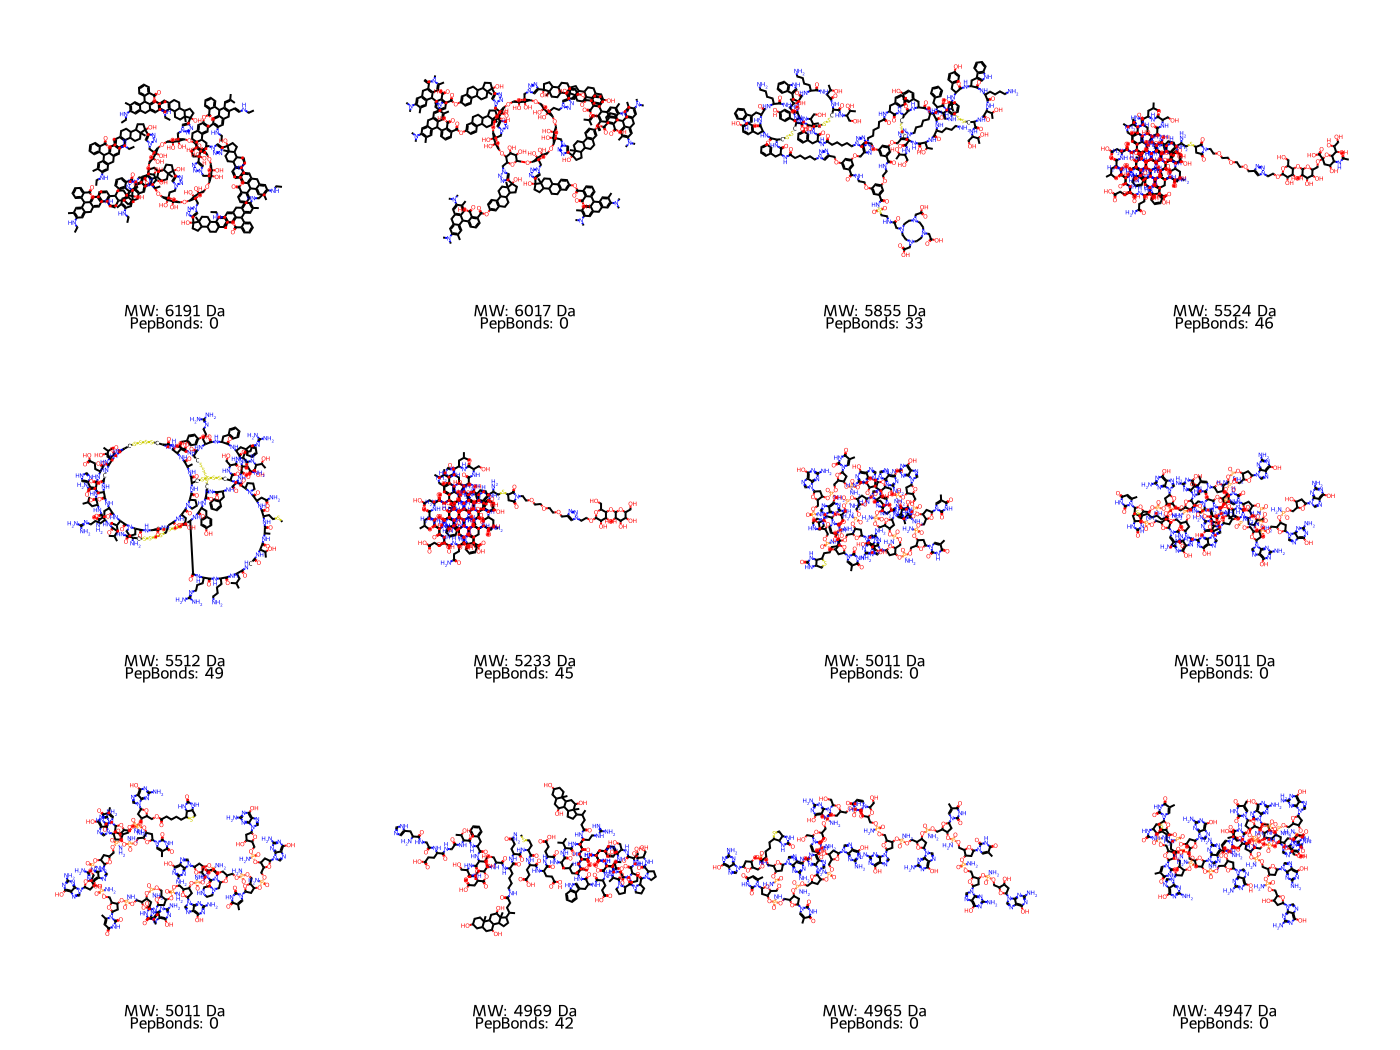

AttributeError: 'Image' object has no attribute 'save'

In [16]:
# =============================================================================
# STEP 4d (cont): Visualize Highest MW Small Molecules
# =============================================================================

from rdkit.Chem import Draw
from IPython.display import display

print("=" * 80)
print("Highest MW Small Molecules")
print("=" * 80)

# Get top 20 highest MW small molecules
top_mw_sm = all_sm_features.nlargest(20, 'molecular_weight')[['SMILES', 'molecular_weight', 'peptide_bond_count', 'peptide_backbone_length']]
top_mw_sm = top_mw_sm.reset_index(drop=True)

print(f"\nTop 20 Highest MW Small Molecules:\n")
print(f"{'Rank':<6} {'MW (Da)':<12} {'Pep Bonds':<12} {'Backbone':<12}")
print("-" * 45)
for i, row in top_mw_sm.iterrows():
    print(f"{i+1:<6} {row['molecular_weight']:<12.1f} {row['peptide_bond_count']:<12.0f} {row['peptide_backbone_length']:<12.0f}")

# Draw top 12 molecules
print("\n\nStructures of Top 12 Highest MW Small Molecules:")
mols = []
legends = []
for i, row in top_mw_sm.head(12).iterrows():
    mol = Chem.MolFromSmiles(row['SMILES'])
    if mol:
        mols.append(mol)
        legends.append(f"MW: {row['molecular_weight']:.0f} Da\nPepBonds: {int(row['peptide_bond_count'])}")

if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(350, 350), legends=legends)
    display(img)
    
    # Save the image
    img.save(f"{OUTPUT_DIR}/highest_mw_small_molecules.png")
    print(f"\nSaved structure image to {OUTPUT_DIR}/highest_mw_small_molecules.png")


In [14]:
# =============================================================================
# STEP 4e: Distribution of Peptide Features in ALL Small Molecules
# =============================================================================

print("=" * 80)
print("STEP 4e: Peptide bond count & backbone length in ALL Small Molecules")
print("=" * 80)

# Get ALL unique SMILES classified as small molecules
all_sm_smiles = papyrus_df[papyrus_df['predicted_mol_class'] == 'sm']['SMILES'].unique()

print(f"\nTotal unique small molecule SMILES: {len(all_sm_smiles):,}")

# Get features for ALL small molecules
all_sm_features = features_df[features_df['SMILES'].isin(all_sm_smiles)].copy()

# Check column names
pep_bond_col_all = 'peptide_bond_count' if 'peptide_bond_count' in all_sm_features.columns else 'pattern_PEPTIDE_BOND'
pep_backbone_col_all = 'peptide_backbone_length' if 'peptide_backbone_length' in all_sm_features.columns else 'pattern_PEPTIDE_BACKBONE'

print(f"Using columns: {pep_bond_col_all}, {pep_backbone_col_all}")
print(f"\nSummary statistics for ALL small molecules:")

# Peptide bond count stats
if pep_bond_col_all in all_sm_features.columns:
    pbc_all = all_sm_features[pep_bond_col_all].fillna(0)
    print(f"\n  Peptide Bond Count:")
    print(f"    Mean: {pbc_all.mean():.3f}")
    print(f"    Median: {pbc_all.median():.3f}")
    print(f"    Max: {pbc_all.max():.0f}")
    print(f"    SMs with >=1 peptide bond: {(pbc_all >= 1).sum():,} ({(pbc_all >= 1).sum()/len(pbc_all)*100:.2f}%)")
    print(f"    SMs with >=2 peptide bonds: {(pbc_all >= 2).sum():,} ({(pbc_all >= 2).sum()/len(pbc_all)*100:.2f}%)")
    print(f"    SMs with >=3 peptide bonds: {(pbc_all >= 3).sum():,} ({(pbc_all >= 3).sum()/len(pbc_all)*100:.2f}%)")

# Peptide backbone length stats  
if pep_backbone_col_all in all_sm_features.columns:
    pbl_all = all_sm_features[pep_backbone_col_all].fillna(0)
    print(f"\n  Peptide Backbone Length:")
    print(f"    Mean: {pbl_all.mean():.3f}")
    print(f"    Median: {pbl_all.median():.3f}")
    print(f"    Max: {pbl_all.max():.0f}")
    print(f"    SMs with backbone >=1: {(pbl_all >= 1).sum():,} ({(pbl_all >= 1).sum()/len(pbl_all)*100:.2f}%)")
    print(f"    SMs with backbone >=2: {(pbl_all >= 2).sum():,} ({(pbl_all >= 2).sum()/len(pbl_all)*100:.2f}%)")


STEP 4e: Peptide bond count & backbone length in ALL Small Molecules

Total unique small molecule SMILES: 1,051,507
Using columns: peptide_bond_count, peptide_backbone_length

Summary statistics for ALL small molecules:

  Peptide Bond Count:
    Mean: 0.410
    Median: 0.000
    Max: 49
    SMs with >=1 peptide bond: 298,389 (28.38%)
    SMs with >=2 peptide bonds: 68,300 (6.50%)
    SMs with >=3 peptide bonds: 18,582 (1.77%)

  Peptide Backbone Length:
    Mean: 0.121
    Median: 0.000
    Max: 44
    SMs with backbone >=1: 69,302 (6.59%)
    SMs with backbone >=2: 18,809 (1.79%)


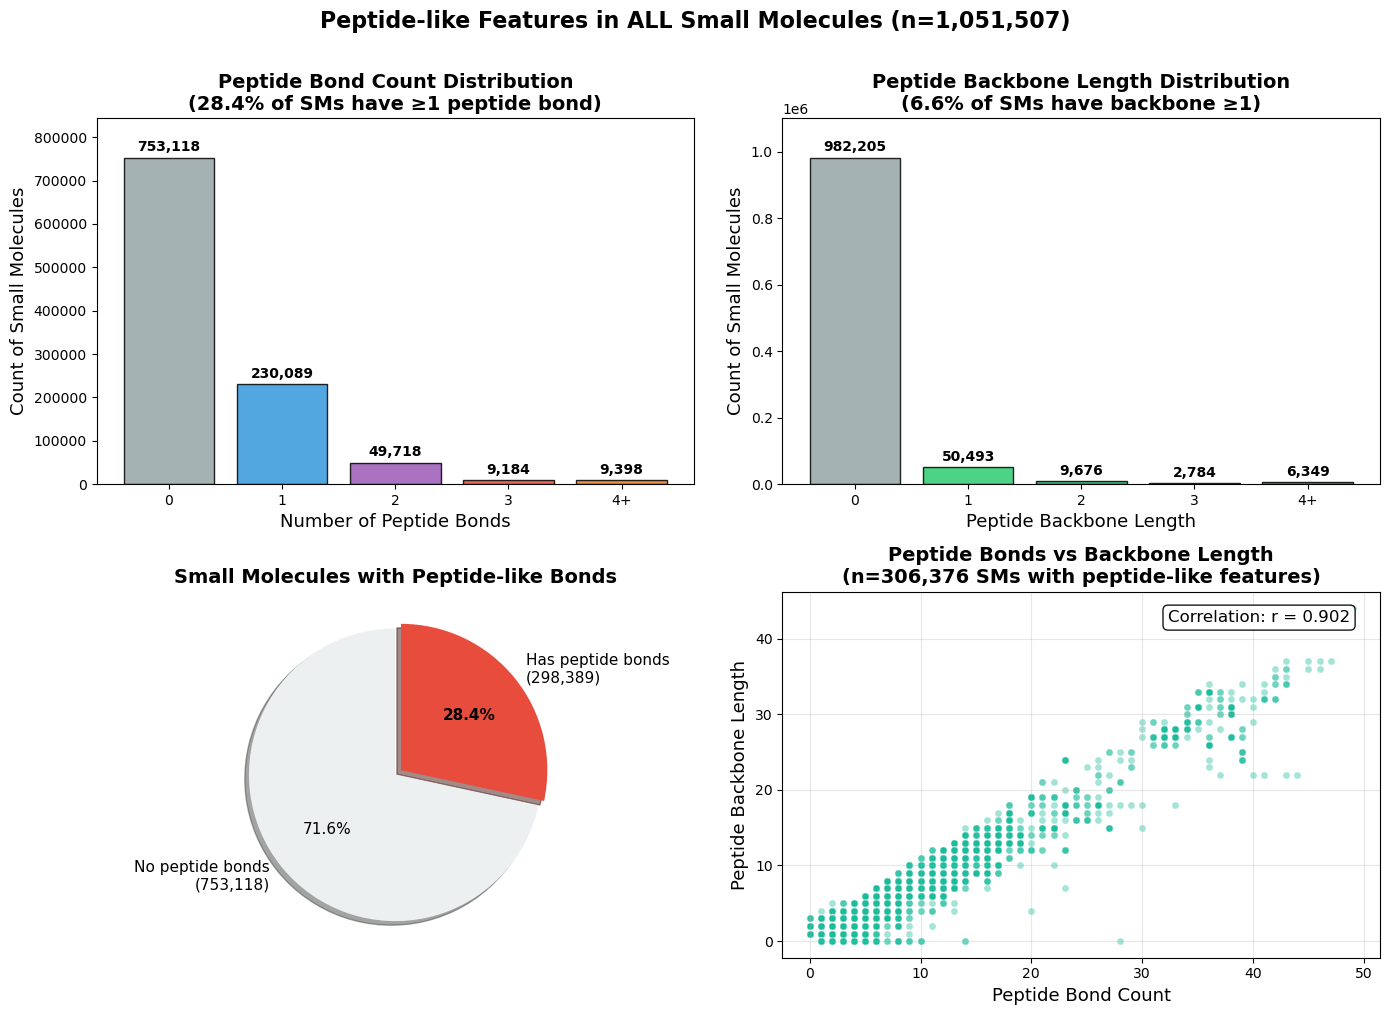


Saved plot to /fsx/amira/papyrus_50.5_results/classified_full/peptide_features_in_all_sm.png


In [15]:
# =============================================================================
# STEP 4e (cont): Visualize Peptide Features Distribution in ALL Small Molecules
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Get data for ALL small molecules
pbc_all = all_sm_features[pep_bond_col_all].fillna(0)
pbl_all = all_sm_features[pep_backbone_col_all].fillna(0)

# Calculate stats for annotations
n_total = len(pbc_all)
n_with_pep_bond = (pbc_all > 0).sum()
n_with_backbone = (pbl_all > 0).sum()
pct_with_pep_bond = n_with_pep_bond / n_total * 100
pct_with_backbone = n_with_backbone / n_total * 100

# ===================
# TOP LEFT: Peptide Bond Count - Category Bar Chart
# ===================
ax1 = axes[0, 0]
categories_pbc = pd.cut(pbc_all, bins=[-1, 0, 1, 2, 3, 100], labels=['0', '1', '2', '3', '4+'])
cat_counts_pbc = categories_pbc.value_counts().sort_index()
colors_pbc = ['#95a5a6', '#3498db', '#9b59b6', '#e74c3c', '#e67e22']
bars1 = ax1.bar(cat_counts_pbc.index, cat_counts_pbc.values, color=colors_pbc, alpha=0.85, edgecolor='black')
ax1.set_xlabel('Number of Peptide Bonds', fontsize=13)
ax1.set_ylabel('Count of Small Molecules', fontsize=13)
ax1.set_title(f'Peptide Bond Count Distribution\n({pct_with_pep_bond:.1f}% of SMs have ≥1 peptide bond)', 
              fontsize=14, fontweight='bold')
# Add count labels on bars
for bar, v in zip(bars1, cat_counts_pbc.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(cat_counts_pbc)*0.01, 
             f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_ylim(0, max(cat_counts_pbc) * 1.12)

# ===================
# TOP RIGHT: Peptide Backbone Length - Category Bar Chart
# ===================
ax2 = axes[0, 1]
categories_pbl = pd.cut(pbl_all, bins=[-1, 0, 1, 2, 3, 100], labels=['0', '1', '2', '3', '4+'])
cat_counts_pbl = categories_pbl.value_counts().sort_index()
colors_pbl = ['#95a5a6', '#2ecc71', '#27ae60', '#1abc9c', '#16a085']
bars2 = ax2.bar(cat_counts_pbl.index, cat_counts_pbl.values, color=colors_pbl, alpha=0.85, edgecolor='black')
ax2.set_xlabel('Peptide Backbone Length', fontsize=13)
ax2.set_ylabel('Count of Small Molecules', fontsize=13)
ax2.set_title(f'Peptide Backbone Length Distribution\n({pct_with_backbone:.1f}% of SMs have backbone ≥1)', 
              fontsize=14, fontweight='bold')
# Add count labels on bars
for bar, v in zip(bars2, cat_counts_pbl.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(cat_counts_pbl)*0.01, 
             f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylim(0, max(cat_counts_pbl) * 1.12)

# ===================
# BOTTOM LEFT: Pie Chart - With vs Without Peptide Bonds
# ===================
ax3 = axes[1, 0]
pie_data = [n_total - n_with_pep_bond, n_with_pep_bond]
pie_labels = [f'No peptide bonds\n({n_total - n_with_pep_bond:,})', 
              f'Has peptide bonds\n({n_with_pep_bond:,})']
pie_colors = ['#ecf0f1', '#e74c3c']
wedges, texts, autotexts = ax3.pie(pie_data, labels=pie_labels, colors=pie_colors, 
                                    autopct='%1.1f%%', startangle=90,
                                    explode=(0, 0.05), shadow=True,
                                    textprops={'fontsize': 11})
autotexts[1].set_fontweight('bold')
ax3.set_title('Small Molecules with Peptide-like Bonds', fontsize=14, fontweight='bold')

# ===================
# BOTTOM RIGHT: Scatter - Bond Count vs Backbone Length (non-zero only)
# ===================
ax4 = axes[1, 1]
mask_nonzero = (pbc_all > 0) | (pbl_all > 0)
if mask_nonzero.sum() > 0:
    ax4.scatter(pbc_all[mask_nonzero], pbl_all[mask_nonzero], 
                c='#1abc9c', alpha=0.4, s=25, edgecolors='white', linewidths=0.3)
    ax4.set_xlabel('Peptide Bond Count', fontsize=13)
    ax4.set_ylabel('Peptide Backbone Length', fontsize=13)
    ax4.set_title(f'Peptide Bonds vs Backbone Length\n(n={mask_nonzero.sum():,} SMs with peptide-like features)', 
                  fontsize=14, fontweight='bold')
    
    # Add correlation
    corr = np.corrcoef(pbc_all[mask_nonzero], pbl_all[mask_nonzero])[0,1]
    ax4.text(0.95, 0.95, f'Correlation: r = {corr:.3f}', transform=ax4.transAxes, fontsize=12, 
             ha='right', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    ax4.grid(True, alpha=0.3)

plt.suptitle(f'Peptide-like Features in ALL Small Molecules (n={n_total:,})', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/peptide_features_in_all_sm.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved plot to {OUTPUT_DIR}/peptide_features_in_all_sm.png")


STEP 4b: Plotting pChEMBL distributions


/tmp/ipykernel_2357345/2112666884.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='mol_class_label', y='pchembl_value_Mean',
/tmp/ipykernel_2357345/2112666884.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='mol_class_label', y='pchembl_value_Mean',


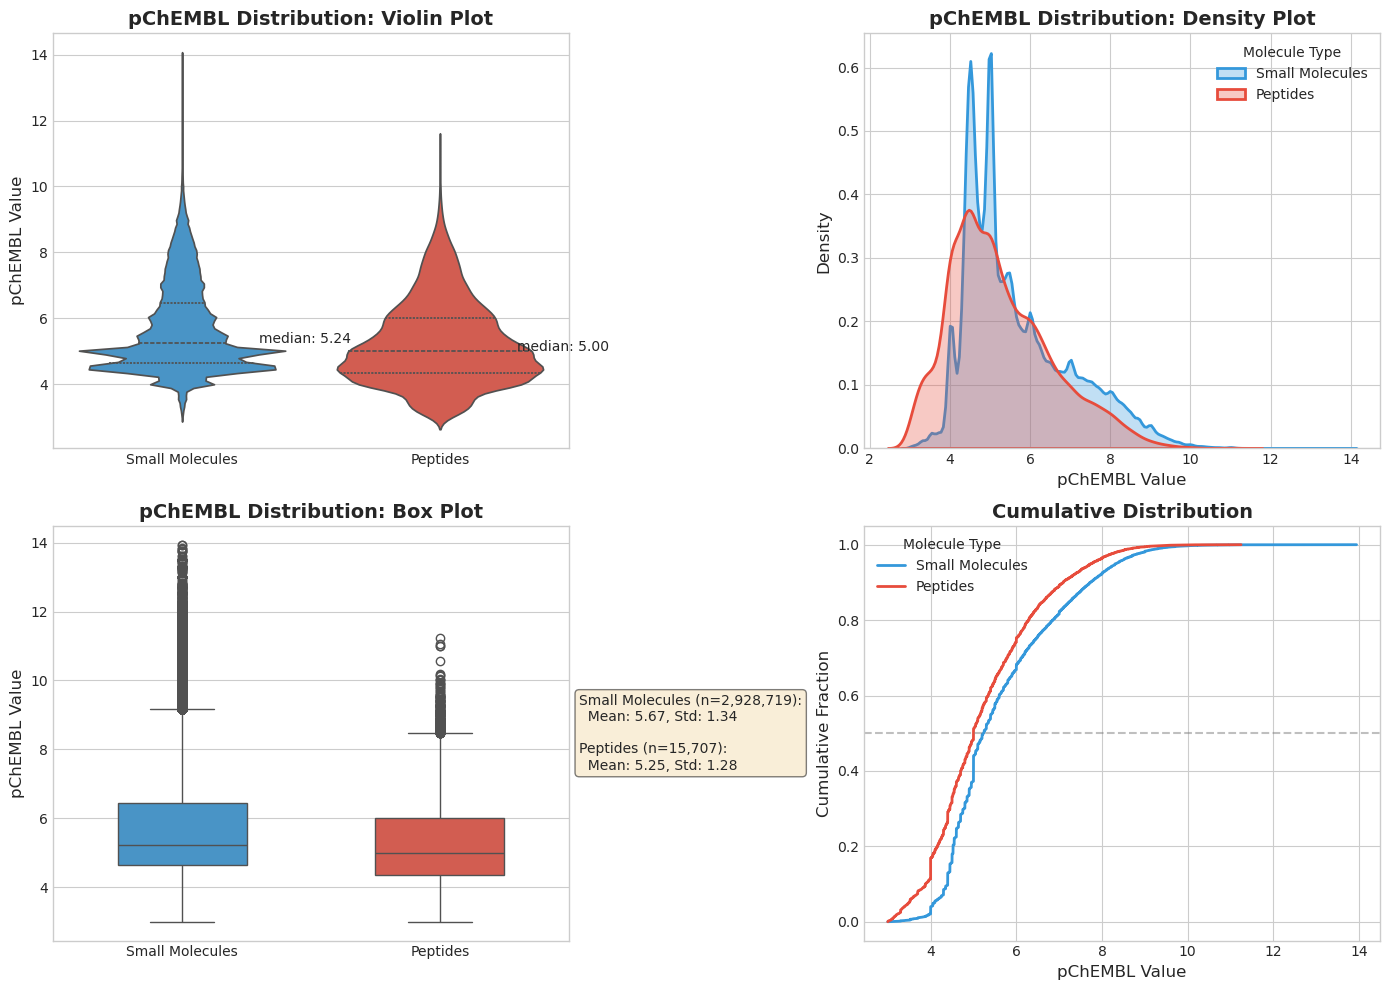


Saved plot to /fsx/amira/papyrus_50.5_results/classified_full/pchembl_sm_vs_peptides.png

ACTIVITY STATISTICS BY MOLECULE CLASS

Metric                    Small Molecules      Peptides            
-----------------------------------------------------------------
Count                     2,928,719            15,707
Mean pChEMBL              5.667                5.252               
Median pChEMBL            5.236                5.000               
Std pChEMBL               1.337                1.275               
Min pChEMBL               3.000                3.001               
Max pChEMBL               13.939               11.244              
25th percentile           4.640                4.350               
75th percentile           6.451                6.000               


In [9]:
# =============================================================================
# STEP 4b: Plot pChEMBL Distribution - Small Molecules vs Peptides
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("STEP 4b: Plotting pChEMBL distributions")
print("=" * 80)

# Filter for SM and peptides only (exclude unwanted)
plot_df = papyrus_df[papyrus_df['predicted_mol_class'].isin(['sm', 'can_peptide'])].copy()
plot_df['mol_class_label'] = plot_df['predicted_mol_class'].map({
    'sm': 'Small Molecules',
    'can_peptide': 'Peptides'
})

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Color palette
colors = {'Small Molecules': '#3498db', 'Peptides': '#e74c3c'}

# -----------------------------------------------------------------------------
# Plot 1: Violin plot
# -----------------------------------------------------------------------------
ax1 = axes[0, 0]
sns.violinplot(data=plot_df, x='mol_class_label', y='pchembl_value_Mean', 
               palette=colors, ax=ax1, inner='quartile')
ax1.set_xlabel('')
ax1.set_ylabel('pChEMBL Value', fontsize=12)
ax1.set_title('pChEMBL Distribution: Violin Plot', fontsize=14, fontweight='bold')

# Add median annotations
for i, cls in enumerate(['Small Molecules', 'Peptides']):
    median = plot_df[plot_df['mol_class_label'] == cls]['pchembl_value_Mean'].median()
    ax1.annotate(f'median: {median:.2f}', xy=(i, median), 
                 xytext=(i + 0.3, median), fontsize=10, ha='left')

# -----------------------------------------------------------------------------
# Plot 2: Histogram / KDE
# -----------------------------------------------------------------------------
ax2 = axes[0, 1]
for cls, color in colors.items():
    subset = plot_df[plot_df['mol_class_label'] == cls]['pchembl_value_Mean']
    sns.kdeplot(data=subset, ax=ax2, color=color, label=cls, fill=True, alpha=0.3, linewidth=2)
ax2.set_xlabel('pChEMBL Value', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('pChEMBL Distribution: Density Plot', fontsize=14, fontweight='bold')
ax2.legend(title='Molecule Type')

# -----------------------------------------------------------------------------
# Plot 3: Box plot by class
# -----------------------------------------------------------------------------
ax3 = axes[1, 0]
sns.boxplot(data=plot_df, x='mol_class_label', y='pchembl_value_Mean', 
            palette=colors, ax=ax3, width=0.5)
ax3.set_xlabel('')
ax3.set_ylabel('pChEMBL Value', fontsize=12)
ax3.set_title('pChEMBL Distribution: Box Plot', fontsize=14, fontweight='bold')

# Add stats
sm_data = plot_df[plot_df['mol_class_label'] == 'Small Molecules']['pchembl_value_Mean']
pep_data = plot_df[plot_df['mol_class_label'] == 'Peptides']['pchembl_value_Mean']
stats_text = f"Small Molecules (n={len(sm_data):,}):\n  Mean: {sm_data.mean():.2f}, Std: {sm_data.std():.2f}\n\n"
stats_text += f"Peptides (n={len(pep_data):,}):\n  Mean: {pep_data.mean():.2f}, Std: {pep_data.std():.2f}"
ax3.text(1.02, 0.5, stats_text, transform=ax3.transAxes, fontsize=10, 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# -----------------------------------------------------------------------------
# Plot 4: Cumulative distribution
# -----------------------------------------------------------------------------
ax4 = axes[1, 1]
for cls, color in colors.items():
    subset = plot_df[plot_df['mol_class_label'] == cls]['pchembl_value_Mean'].sort_values()
    cumulative = np.arange(1, len(subset) + 1) / len(subset)
    ax4.plot(subset, cumulative, color=color, label=cls, linewidth=2)
ax4.set_xlabel('pChEMBL Value', fontsize=12)
ax4.set_ylabel('Cumulative Fraction', fontsize=12)
ax4.set_title('Cumulative Distribution', fontsize=14, fontweight='bold')
ax4.legend(title='Molecule Type')
ax4.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50%')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pchembl_sm_vs_peptides.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved plot to {OUTPUT_DIR}/pchembl_sm_vs_peptides.png")

# Print summary statistics
print(f"\n{'='*60}")
print("ACTIVITY STATISTICS BY MOLECULE CLASS")
print(f"{'='*60}")
print(f"\n{'Metric':<25} {'Small Molecules':<20} {'Peptides':<20}")
print("-" * 65)
print(f"{'Count':<25} {len(sm_data):,}{'':<11} {len(pep_data):,}")
print(f"{'Mean pChEMBL':<25} {sm_data.mean():<20.3f} {pep_data.mean():<20.3f}")
print(f"{'Median pChEMBL':<25} {sm_data.median():<20.3f} {pep_data.median():<20.3f}")
print(f"{'Std pChEMBL':<25} {sm_data.std():<20.3f} {pep_data.std():<20.3f}")
print(f"{'Min pChEMBL':<25} {sm_data.min():<20.3f} {pep_data.min():<20.3f}")
print(f"{'Max pChEMBL':<25} {sm_data.max():<20.3f} {pep_data.max():<20.3f}")
print(f"{'25th percentile':<25} {sm_data.quantile(0.25):<20.3f} {pep_data.quantile(0.25):<20.3f}")
print(f"{'75th percentile':<25} {sm_data.quantile(0.75):<20.3f} {pep_data.quantile(0.75):<20.3f}")


STEP 4c: Plotting pChEMBL distributions (TOP 100 PEPTIDE-RICH TARGETS)

Filtering for top 100 targets with most peptide binders...
Top 100 targets have 7,819 total peptide binders
Records in top 100 targets: 924,741
  - Small molecules: 916,922
  - Peptides: 7,819


/tmp/ipykernel_2357345/3357587776.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=top100_df, x='mol_class_label', y='pchembl_value_Mean',
/tmp/ipykernel_2357345/3357587776.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=top100_df, x='mol_class_label', y='pchembl_value_Mean',


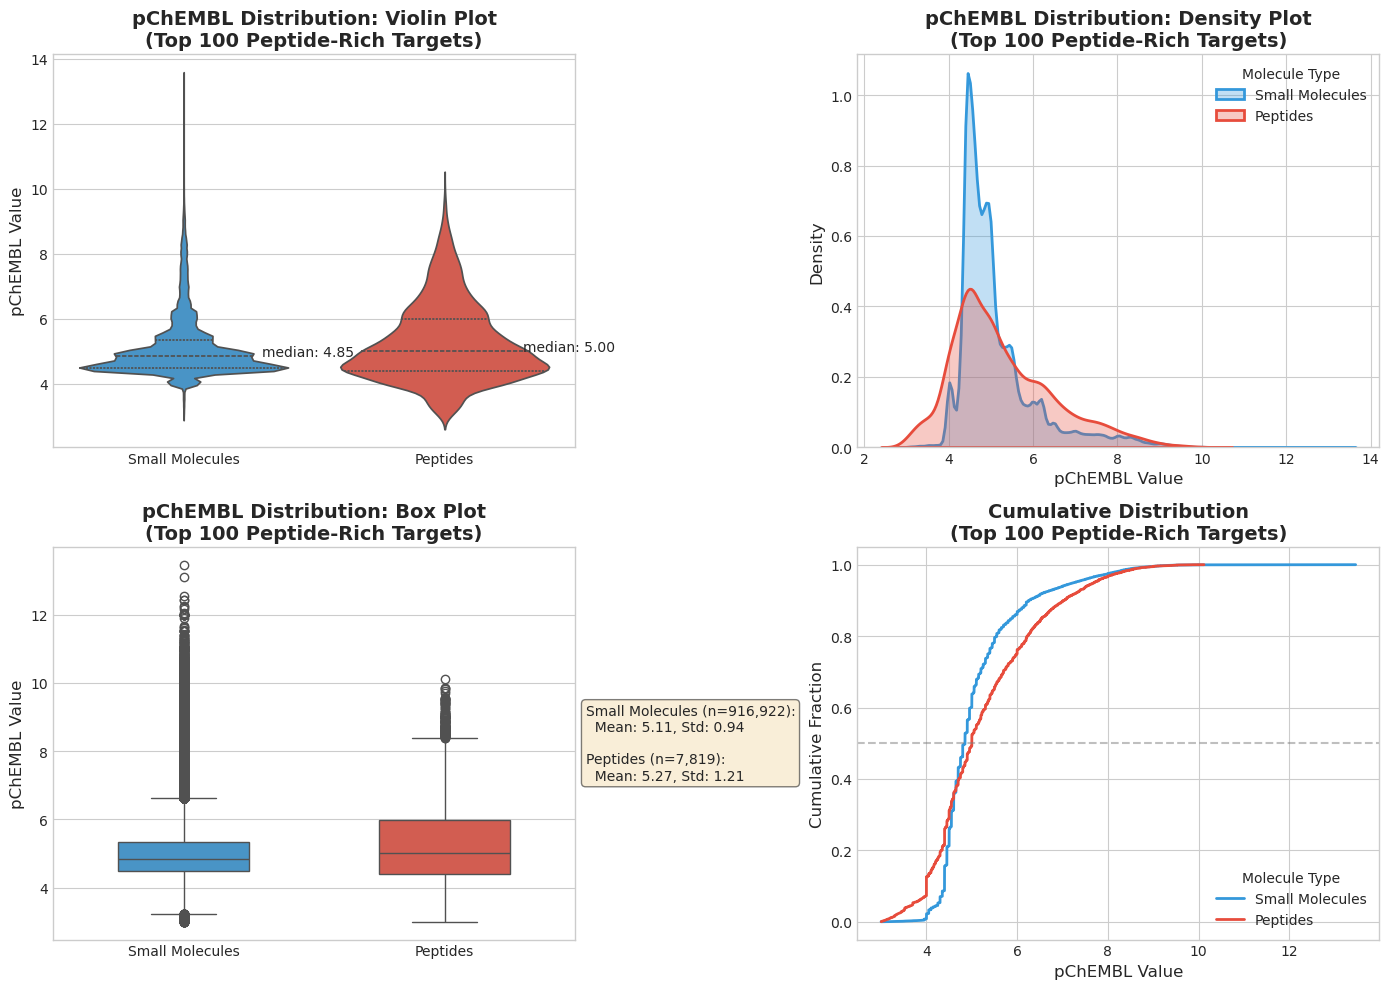


Saved plot to /fsx/amira/papyrus_50.5_results/classified_full/pchembl_sm_vs_peptides_top100.png

ACTIVITY STATISTICS - TOP 100 TARGETS

Metric                    Small Molecules      Peptides            
-----------------------------------------------------------------
Count                     916,922            7,819
Mean pChEMBL              5.111                5.267               
Median pChEMBL            4.850                5.000               
Std pChEMBL               0.942                1.209               
Min pChEMBL               3.000                3.004               
Max pChEMBL               13.463               10.120              
25th percentile           4.500                4.400               
75th percentile           5.350                5.992               


In [10]:
# =============================================================================
# STEP 4c: Plot pChEMBL Distribution - TOP 100 TARGETS ONLY
# =============================================================================

print("=" * 80)
print("STEP 4c: Plotting pChEMBL distributions (TOP 100 PEPTIDE-RICH TARGETS)")
print("=" * 80)

# Get top 100 targets by peptide count
top_100_targets = target_ranking.head(100)['accession'].tolist()
print(f"\nFiltering for top 100 targets with most peptide binders...")
print(f"Top 100 targets have {target_ranking.head(100)['can_peptide'].sum():,} total peptide binders")

# Filter data for top 100 targets
top100_df = papyrus_df[papyrus_df['accession'].isin(top_100_targets)].copy()
top100_df = top100_df[top100_df['predicted_mol_class'].isin(['sm', 'can_peptide'])]
top100_df['mol_class_label'] = top100_df['predicted_mol_class'].map({
    'sm': 'Small Molecules',
    'can_peptide': 'Peptides'
})

print(f"Records in top 100 targets: {len(top100_df):,}")
print(f"  - Small molecules: {(top100_df['predicted_mol_class'] == 'sm').sum():,}")
print(f"  - Peptides: {(top100_df['predicted_mol_class'] == 'can_peptide').sum():,}")

# Create plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Color palette
colors = {'Small Molecules': '#3498db', 'Peptides': '#e74c3c'}

# -----------------------------------------------------------------------------
# Plot 1: Violin plot
# -----------------------------------------------------------------------------
ax1 = axes[0, 0]
sns.violinplot(data=top100_df, x='mol_class_label', y='pchembl_value_Mean', 
               palette=colors, ax=ax1, inner='quartile')
ax1.set_xlabel('')
ax1.set_ylabel('pChEMBL Value', fontsize=12)
ax1.set_title('pChEMBL Distribution: Violin Plot\n(Top 100 Peptide-Rich Targets)', fontsize=14, fontweight='bold')

# Add median annotations
for i, cls in enumerate(['Small Molecules', 'Peptides']):
    median = top100_df[top100_df['mol_class_label'] == cls]['pchembl_value_Mean'].median()
    ax1.annotate(f'median: {median:.2f}', xy=(i, median), 
                 xytext=(i + 0.3, median), fontsize=10, ha='left')

# -----------------------------------------------------------------------------
# Plot 2: Histogram / KDE
# -----------------------------------------------------------------------------
ax2 = axes[0, 1]
for cls, color in colors.items():
    subset = top100_df[top100_df['mol_class_label'] == cls]['pchembl_value_Mean']
    sns.kdeplot(data=subset, ax=ax2, color=color, label=cls, fill=True, alpha=0.3, linewidth=2)
ax2.set_xlabel('pChEMBL Value', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('pChEMBL Distribution: Density Plot\n(Top 100 Peptide-Rich Targets)', fontsize=14, fontweight='bold')
ax2.legend(title='Molecule Type')

# -----------------------------------------------------------------------------
# Plot 3: Box plot by class
# -----------------------------------------------------------------------------
ax3 = axes[1, 0]
sns.boxplot(data=top100_df, x='mol_class_label', y='pchembl_value_Mean', 
            palette=colors, ax=ax3, width=0.5)
ax3.set_xlabel('')
ax3.set_ylabel('pChEMBL Value', fontsize=12)
ax3.set_title('pChEMBL Distribution: Box Plot\n(Top 100 Peptide-Rich Targets)', fontsize=14, fontweight='bold')

# Add stats
sm_data_top100 = top100_df[top100_df['mol_class_label'] == 'Small Molecules']['pchembl_value_Mean']
pep_data_top100 = top100_df[top100_df['mol_class_label'] == 'Peptides']['pchembl_value_Mean']
stats_text = f"Small Molecules (n={len(sm_data_top100):,}):\n  Mean: {sm_data_top100.mean():.2f}, Std: {sm_data_top100.std():.2f}\n\n"
stats_text += f"Peptides (n={len(pep_data_top100):,}):\n  Mean: {pep_data_top100.mean():.2f}, Std: {pep_data_top100.std():.2f}"
ax3.text(1.02, 0.5, stats_text, transform=ax3.transAxes, fontsize=10, 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# -----------------------------------------------------------------------------
# Plot 4: Cumulative distribution
# -----------------------------------------------------------------------------
ax4 = axes[1, 1]
for cls, color in colors.items():
    subset = top100_df[top100_df['mol_class_label'] == cls]['pchembl_value_Mean'].sort_values()
    cumulative = np.arange(1, len(subset) + 1) / len(subset)
    ax4.plot(subset, cumulative, color=color, label=cls, linewidth=2)
ax4.set_xlabel('pChEMBL Value', fontsize=12)
ax4.set_ylabel('Cumulative Fraction', fontsize=12)
ax4.set_title('Cumulative Distribution\n(Top 100 Peptide-Rich Targets)', fontsize=14, fontweight='bold')
ax4.legend(title='Molecule Type')
ax4.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pchembl_sm_vs_peptides_top100.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved plot to {OUTPUT_DIR}/pchembl_sm_vs_peptides_top100.png")

# Print summary statistics
print(f"\n{'='*60}")
print("ACTIVITY STATISTICS - TOP 100 TARGETS")
print(f"{'='*60}")
print(f"\n{'Metric':<25} {'Small Molecules':<20} {'Peptides':<20}")
print("-" * 65)
print(f"{'Count':<25} {len(sm_data_top100):,}{'':<11} {len(pep_data_top100):,}")
print(f"{'Mean pChEMBL':<25} {sm_data_top100.mean():<20.3f} {pep_data_top100.mean():<20.3f}")
print(f"{'Median pChEMBL':<25} {sm_data_top100.median():<20.3f} {pep_data_top100.median():<20.3f}")
print(f"{'Std pChEMBL':<25} {sm_data_top100.std():<20.3f} {pep_data_top100.std():<20.3f}")
print(f"{'Min pChEMBL':<25} {sm_data_top100.min():<20.3f} {pep_data_top100.min():<20.3f}")
print(f"{'Max pChEMBL':<25} {sm_data_top100.max():<20.3f} {pep_data_top100.max():<20.3f}")
print(f"{'25th percentile':<25} {sm_data_top100.quantile(0.25):<20.3f} {pep_data_top100.quantile(0.25):<20.3f}")
print(f"{'75th percentile':<25} {sm_data_top100.quantile(0.75):<20.3f} {pep_data_top100.quantile(0.75):<20.3f}")


STEP 4d: pChEMBL distributions per target (Top 100)


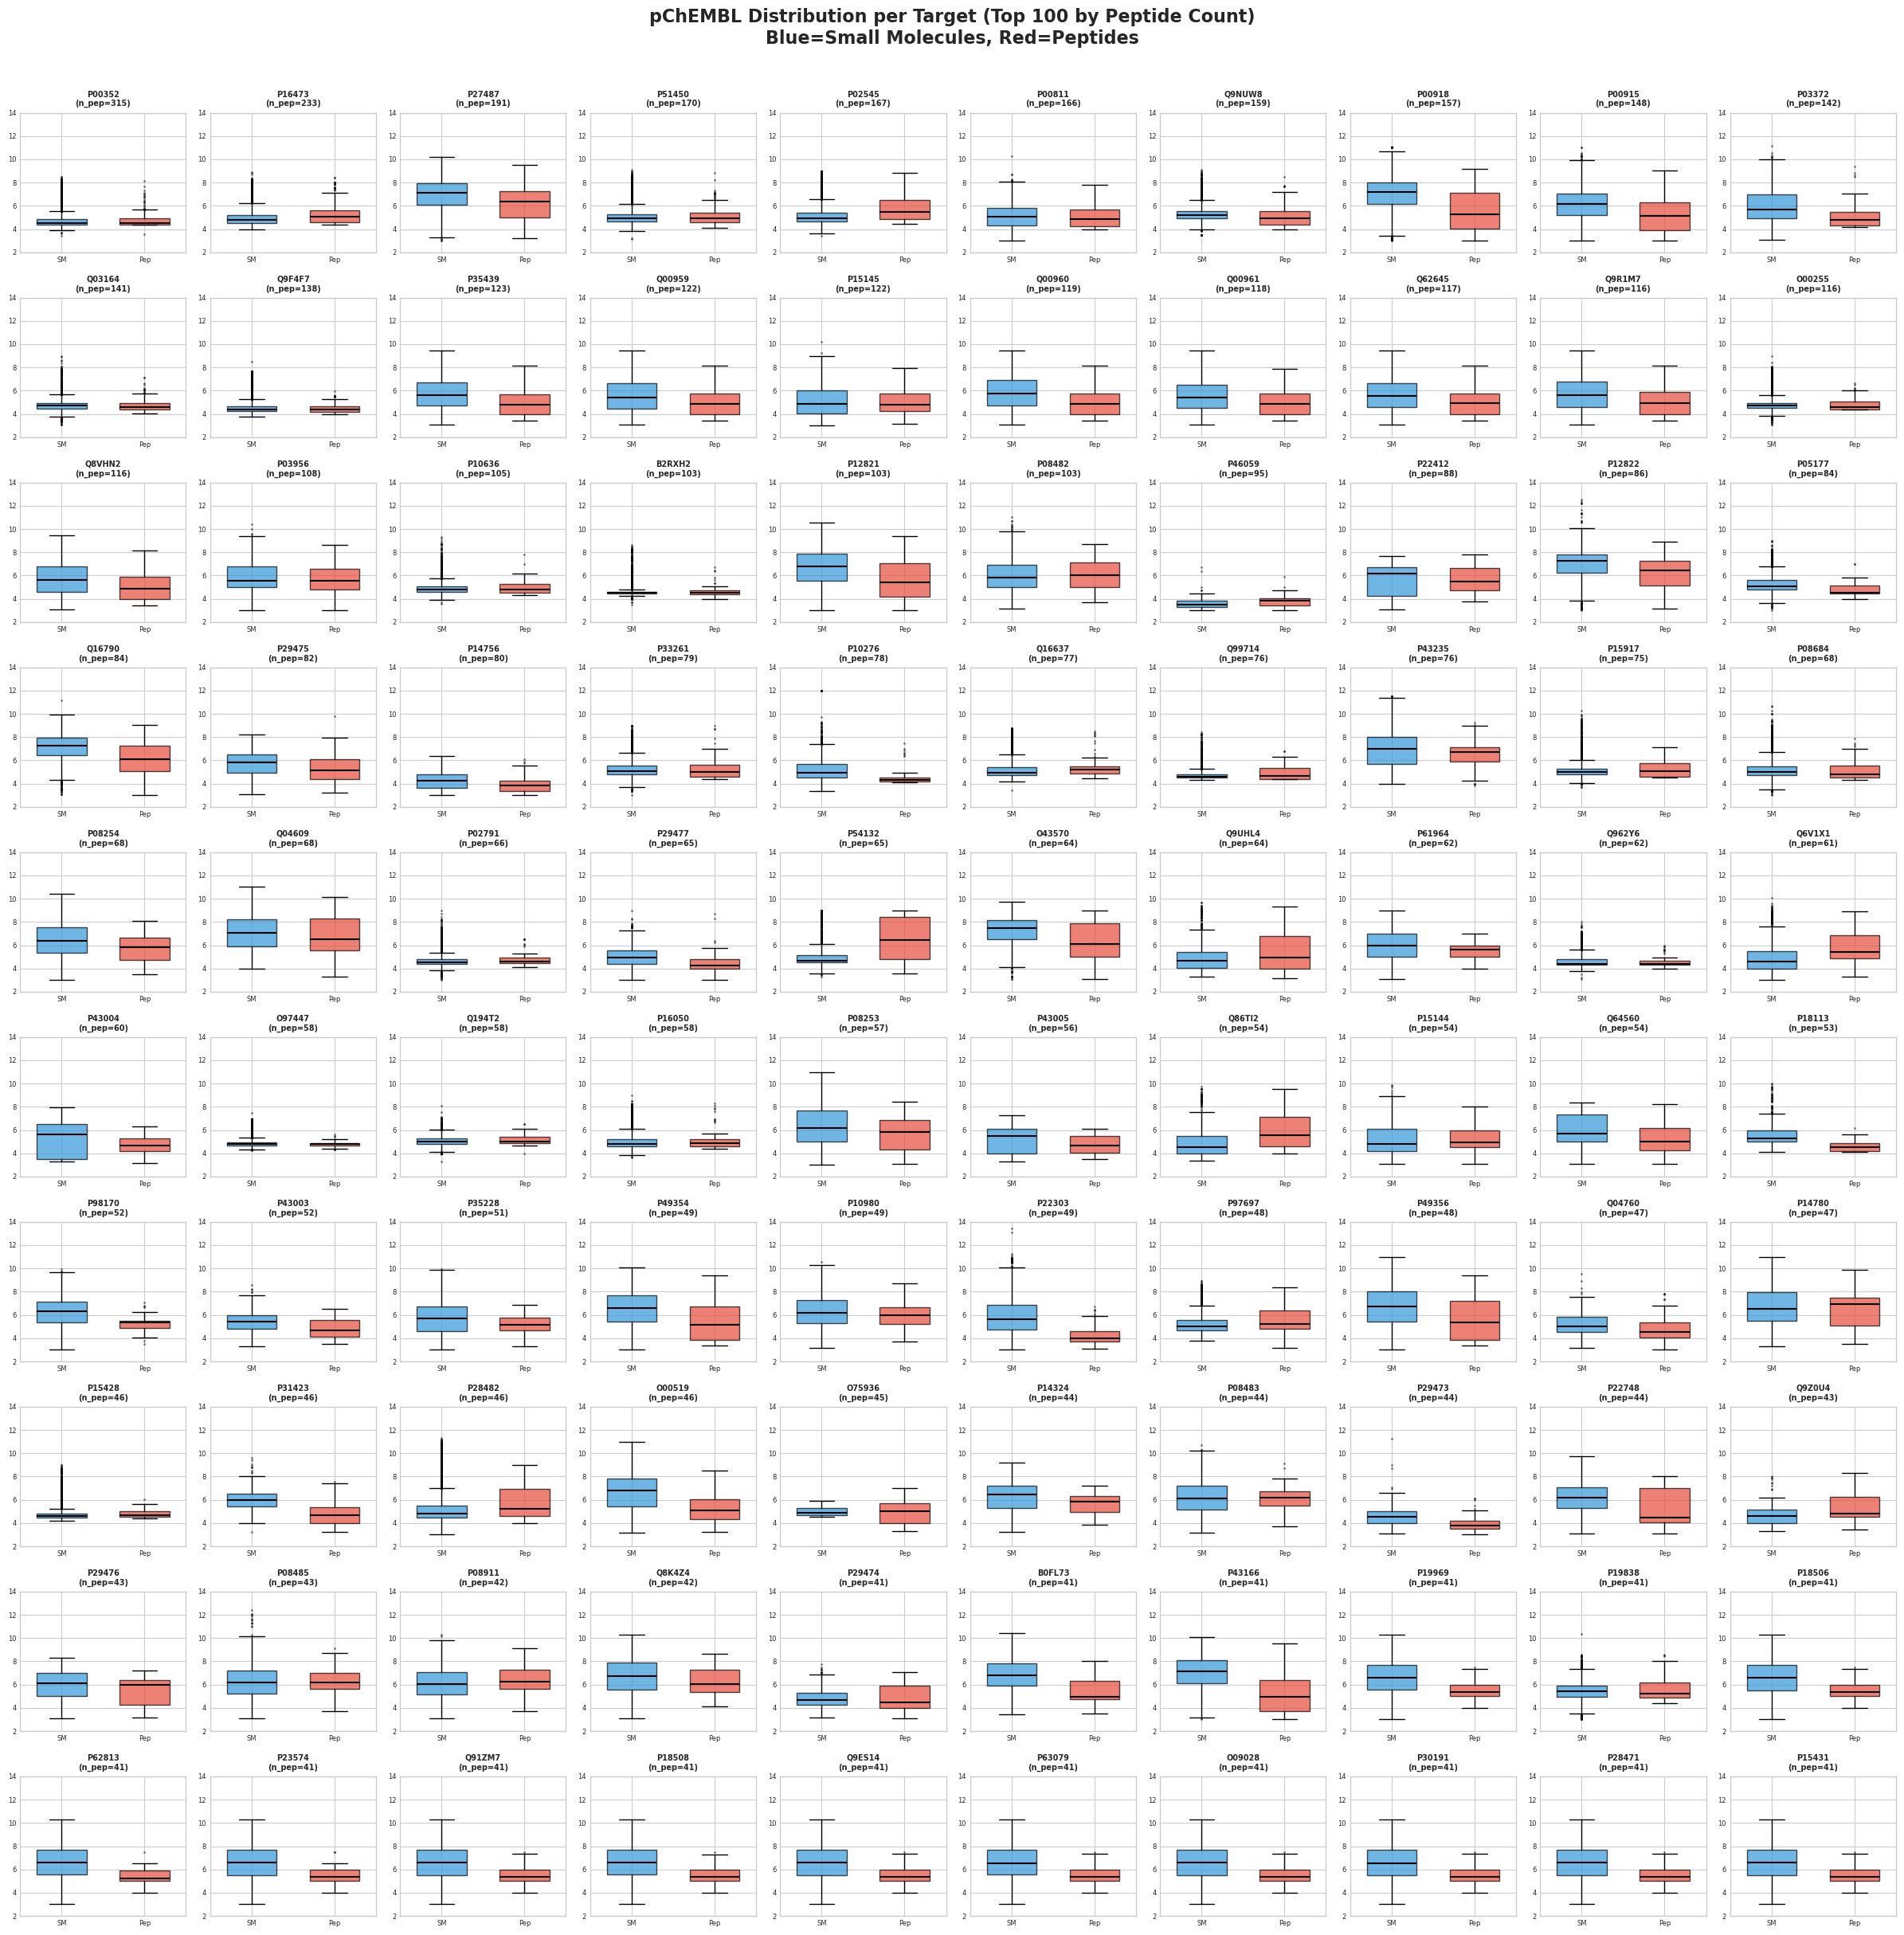


Saved grid plot to /fsx/amira/papyrus_50.5_results/classified_full/pchembl_per_target_top100_grid.png


In [ ]:
# =============================================================================
# STEP 4d: pChEMBL Distribution PER TARGET (Top 100)
# =============================================================================

print("=" * 80)
print("STEP 4d: pChEMBL distributions per target (Top 100)")
print("=" * 80)

# Get top 100 targets
top_100_targets = target_ranking.head(100)['accession'].tolist()

# Prepare data for each target
target_stats = []
for acc in top_100_targets:
    target_data = papyrus_df[papyrus_df['accession'] == acc]
    
    sm_vals = target_data[target_data['predicted_mol_class'] == 'sm']['pchembl_value_Mean']
    pep_vals = target_data[target_data['predicted_mol_class'] == 'can_peptide']['pchembl_value_Mean']
    
    target_stats.append({
        'accession': acc,
        'n_sm': len(sm_vals),
        'n_pep': len(pep_vals),
        'sm_mean': sm_vals.mean() if len(sm_vals) > 0 else np.nan,
        'pep_mean': pep_vals.mean() if len(pep_vals) > 0 else np.nan,
        'sm_median': sm_vals.median() if len(sm_vals) > 0 else np.nan,
        'pep_median': pep_vals.median() if len(pep_vals) > 0 else np.nan,
    })

target_stats_df = pd.DataFrame(target_stats)

# Create a large figure with 10x10 grid of box plots
n_cols = 10
n_rows = 10
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 24))
axes = axes.flatten()

colors = {'sm': '#3498db', 'can_peptide': '#e74c3c'}

for idx, acc in enumerate(top_100_targets):
    ax = axes[idx]
    
    target_data = papyrus_df[papyrus_df['accession'] == acc]
    target_data = target_data[target_data['predicted_mol_class'].isin(['sm', 'can_peptide'])]
    
    if len(target_data) > 0:
        # Create box plot
        plot_data = []
        positions = []
        colors_list = []
        
        sm_vals = target_data[target_data['predicted_mol_class'] == 'sm']['pchembl_value_Mean'].values
        pep_vals = target_data[target_data['predicted_mol_class'] == 'can_peptide']['pchembl_value_Mean'].values
        
        if len(sm_vals) > 0:
            bp1 = ax.boxplot([sm_vals], positions=[0], widths=0.6, patch_artist=True,
                            boxprops=dict(facecolor='#3498db', alpha=0.7),
                            medianprops=dict(color='black', linewidth=1.5),
                            flierprops=dict(marker='.', markersize=2, alpha=0.5))
        
        if len(pep_vals) > 0:
            bp2 = ax.boxplot([pep_vals], positions=[1], widths=0.6, patch_artist=True,
                            boxprops=dict(facecolor='#e74c3c', alpha=0.7),
                            medianprops=dict(color='black', linewidth=1.5),
                            flierprops=dict(marker='.', markersize=2, alpha=0.5))
        
        ax.set_xlim(-0.5, 1.5)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['SM', 'Pep'], fontsize=7)
        ax.set_ylim(2, 14)
        
        # Get peptide count for ranking info
        n_pep = len(pep_vals)
        ax.set_title(f'{acc}\n(n_pep={n_pep})', fontsize=7, fontweight='bold')
    else:
        ax.set_visible(False)
    
    ax.tick_params(axis='both', labelsize=6)

# Add overall title and legend
fig.suptitle('pChEMBL Distribution per Target (Top 100 by Peptide Count)\nBlue=Small Molecules, Red=Peptides', 
             fontsize=16, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pchembl_per_target_top100_grid.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved grid plot to {OUTPUT_DIR}/pchembl_per_target_top100_grid.png")


STEP 4e: Summary comparison - SM vs Peptide activity per target

Targets with both SM and peptide data: 100


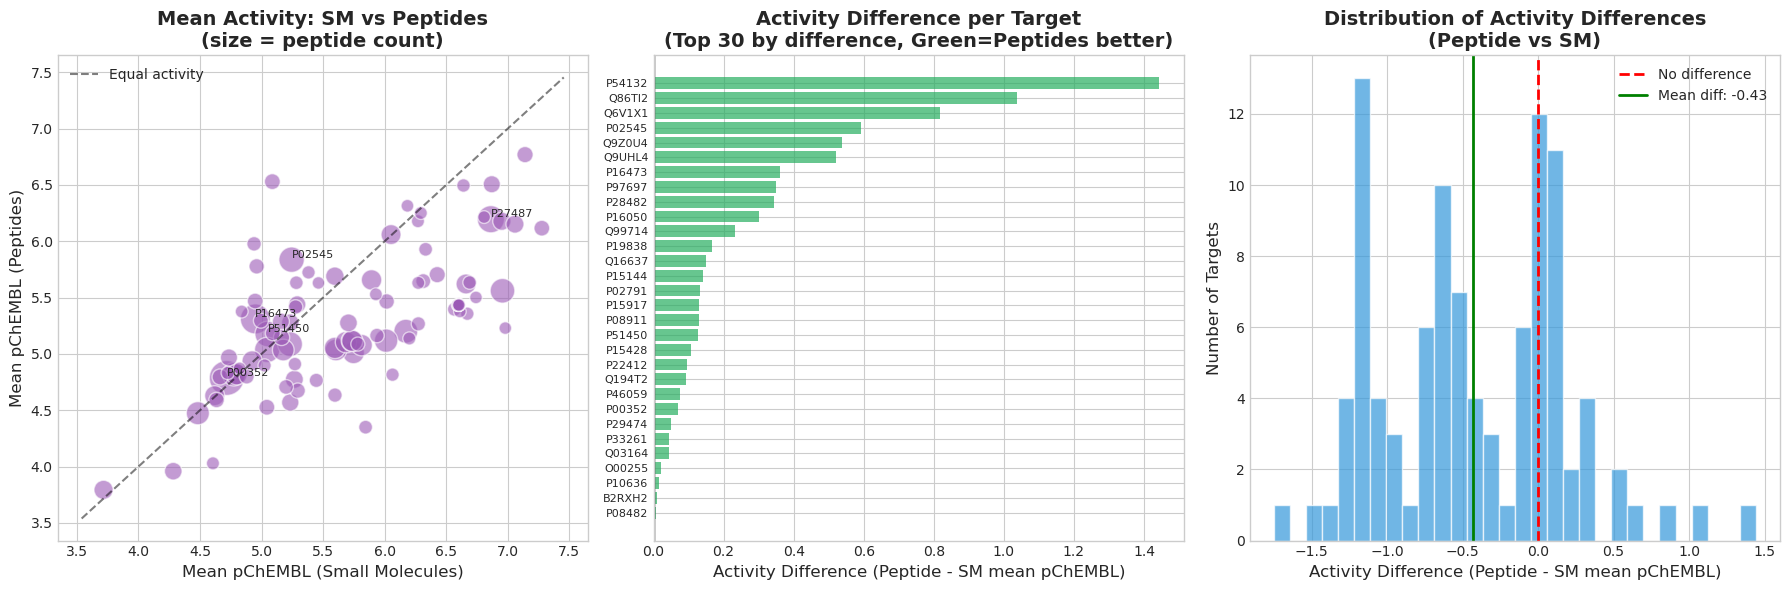


Saved comparison plot to /fsx/amira/papyrus_50.5_results/classified_full/pchembl_sm_vs_peptides_comparison.png

ACTIVITY COMPARISON SUMMARY
Targets where peptides have higher mean activity: 30 (30.0%)
Targets where SMs have higher mean activity: 70 (70.0%)
Mean activity difference (Pep - SM): -0.429
Median activity difference (Pep - SM): -0.492


In [12]:
# =============================================================================
# STEP 4e: Summary Comparison - SM vs Peptide Activity per Target
# =============================================================================

print("=" * 80)
print("STEP 4e: Summary comparison - SM vs Peptide activity per target")
print("=" * 80)

# Filter targets with both SM and peptide data
valid_targets = target_stats_df[
    (target_stats_df['n_sm'] > 0) & 
    (target_stats_df['n_pep'] > 0)
].copy()

print(f"\nTargets with both SM and peptide data: {len(valid_targets)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# -----------------------------------------------------------------------------
# Plot 1: Scatter plot - Mean pChEMBL (SM vs Peptide)
# -----------------------------------------------------------------------------
ax1 = axes[0]
scatter = ax1.scatter(valid_targets['sm_mean'], valid_targets['pep_mean'], 
                      s=valid_targets['n_pep']*2, alpha=0.6, c='#9b59b6', edgecolors='white')

# Add diagonal line (equal activity)
lims = [min(ax1.get_xlim()[0], ax1.get_ylim()[0]), max(ax1.get_xlim()[1], ax1.get_ylim()[1])]
ax1.plot(lims, lims, 'k--', alpha=0.5, label='Equal activity')

ax1.set_xlabel('Mean pChEMBL (Small Molecules)', fontsize=12)
ax1.set_ylabel('Mean pChEMBL (Peptides)', fontsize=12)
ax1.set_title('Mean Activity: SM vs Peptides\n(size = peptide count)', fontsize=14, fontweight='bold')
ax1.legend()

# Annotate top targets (by peptide count)
top_5 = valid_targets.nlargest(5, 'n_pep')
for _, row in top_5.iterrows():
    ax1.annotate(row['accession'], (row['sm_mean'], row['pep_mean']), 
                 fontsize=8, ha='left', va='bottom')

# -----------------------------------------------------------------------------
# Plot 2: Bar chart - Activity difference (Peptide - SM)
# -----------------------------------------------------------------------------
ax2 = axes[1]
valid_targets['activity_diff'] = valid_targets['pep_mean'] - valid_targets['sm_mean']
sorted_targets = valid_targets.sort_values('activity_diff', ascending=False).head(30)

colors = ['#27ae60' if x > 0 else '#e74c3c' for x in sorted_targets['activity_diff']]
bars = ax2.barh(range(len(sorted_targets)), sorted_targets['activity_diff'], color=colors, alpha=0.7)
ax2.set_yticks(range(len(sorted_targets)))
ax2.set_yticklabels(sorted_targets['accession'], fontsize=8)
ax2.axvline(x=0, color='black', linewidth=1)
ax2.set_xlabel('Activity Difference (Peptide - SM mean pChEMBL)', fontsize=12)
ax2.set_title('Activity Difference per Target\n(Top 30 by difference, Green=Peptides better)', fontsize=14, fontweight='bold')
ax2.invert_yaxis()

# -----------------------------------------------------------------------------
# Plot 3: Distribution of activity differences
# -----------------------------------------------------------------------------
ax3 = axes[2]
diff_values = valid_targets['activity_diff'].dropna()
ax3.hist(diff_values, bins=30, color='#3498db', alpha=0.7, edgecolor='white')
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No difference')
ax3.axvline(x=diff_values.mean(), color='green', linestyle='-', linewidth=2, 
            label=f'Mean diff: {diff_values.mean():.2f}')
ax3.set_xlabel('Activity Difference (Peptide - SM mean pChEMBL)', fontsize=12)
ax3.set_ylabel('Number of Targets', fontsize=12)
ax3.set_title('Distribution of Activity Differences\n(Peptide vs SM)', fontsize=14, fontweight='bold')
ax3.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pchembl_sm_vs_peptides_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved comparison plot to {OUTPUT_DIR}/pchembl_sm_vs_peptides_comparison.png")

# Print summary
n_pep_better = (valid_targets['activity_diff'] > 0).sum()
n_sm_better = (valid_targets['activity_diff'] < 0).sum()
print(f"\n{'='*60}")
print("ACTIVITY COMPARISON SUMMARY")
print(f"{'='*60}")
print(f"Targets where peptides have higher mean activity: {n_pep_better} ({n_pep_better/len(valid_targets)*100:.1f}%)")
print(f"Targets where SMs have higher mean activity: {n_sm_better} ({n_sm_better/len(valid_targets)*100:.1f}%)")
print(f"Mean activity difference (Pep - SM): {diff_values.mean():.3f}")
print(f"Median activity difference (Pep - SM): {diff_values.median():.3f}")


In [ ]:
# =============================================================================
# STEP 4f: Overlap with Target Prioritization List
# =============================================================================

print("=" * 80)
print("STEP 4f: Checking overlap with Target Prioritization List")
print("=" * 80)

# Load target prioritization file
prioritization_file = "/fsx/amira/papyrus_target_prioritization/TargetPrioritization_PBS_IDs_Nov2025.csv"
priority_df = pd.read_csv(prioritization_file)

print(f"\nLoaded prioritization file: {prioritization_file}")
print(f"Number of priority targets: {len(priority_df)}")
print(f"Columns: {priority_df.columns.tolist()}")

# Get UniProt IDs from prioritization file (check common column names)
uniprot_col = "Uniprot ID"
for col in ['UniProt_ID', 'UniProtID', 'uniprot_id', 'accession', 'Accession', 'UniProt', 'ID']:
    if col in priority_df.columns:
        uniprot_col = col
        break

if uniprot_col is None:
    print("\nAvailable columns:")
    print(priority_df.head())
    print("\nPlease identify the UniProt ID column from the above")
else:
    priority_targets = set(priority_df[uniprot_col].dropna().unique())
    print(f"\nUsing column '{uniprot_col}' for UniProt IDs")
    print(f"Unique priority targets: {len(priority_targets)}")
    
    # Get top 100 targets from our ranking
    top_100_set = set(target_ranking.head(100)['accession'].tolist())
    
    # Find overlaps
    overlap = top_100_set.intersection(priority_targets)
    
    print(f"\n{'='*60}")
    print("OVERLAP ANALYSIS")
    print(f"{'='*60}")
    print(f"\nTop 100 peptide-rich targets: {len(top_100_set)}")
    print(f"Priority targets: {len(priority_targets)}")
    print(f"OVERLAP: {len(overlap)} targets ({len(overlap)/len(top_100_set)*100:.1f}% of top 100)")
    
    if len(overlap) > 0:
        print(f"\n{'='*60}")
        print("OVERLAPPING TARGETS (in priority list AND top 100 peptide-rich)")
        print(f"{'='*60}")
        
        # Get details for overlapping targets
        overlap_details = target_ranking[target_ranking['accession'].isin(overlap)].copy()
        overlap_details = overlap_details.sort_values('rank')
        
        print(f"\n{'Rank':<6} {'Target':<15} {'Peptides':<12} {'SMs':<12} {'%Peptide':<10}")
        print("-" * 60)
        for _, row in overlap_details.iterrows():
            print(f"{row['rank']:<6} {row['accession']:<15} {row['can_peptide']:<12} {row['sm']:<12} {row['peptide_percent']:.1f}%")
        
        # Save overlap to file
        overlap_output = f"{OUTPUT_DIR}/overlap_priority_top100_peptide.tsv"
        overlap_details.to_csv(overlap_output, sep='\t', index=False)
        print(f"\nSaved overlap details to {overlap_output}")
        
        # Also show which priority targets are NOT in top 100
        priority_not_in_top100 = priority_targets - top_100_set
        print(f"\nPriority targets NOT in top 100 peptide-rich: {len(priority_not_in_top100)}")
        
        # Check if any priority targets have peptides at all
        priority_in_papyrus = target_ranking[target_ranking['accession'].isin(priority_targets)]
        if len(priority_in_papyrus) > 0:
            print(f"\nPriority targets found in Papyrus (any rank): {len(priority_in_papyrus)}")
            priority_with_peptides = priority_in_papyrus[priority_in_papyrus['can_peptide'] > 0]
            print(f"Priority targets with ANY peptide binders: {len(priority_with_peptides)}")
    else:
        print("\nNo overlap found between top 100 peptide-rich targets and priority list.")


STEP 4f: Checking overlap with Target Prioritization List

Loaded prioritization file: /fsx/amira/papyrus_target_prioritization/TargetPrioritization_PBS_IDs_Nov2025.csv
Number of priority targets: 56
Columns: ['Gene name', 'Protein name', 'Cortellis', 'ChEMBL', 'Uniprot ID', 'Protein sequence', 'PDB apo', 'PDB holo + peptide', 'PDB holo + SM']

Using column 'Uniprot ID' for UniProt IDs
Unique priority targets: 56

OVERLAP ANALYSIS

Top 100 peptide-rich targets: 100
Priority targets: 56
OVERLAP: 0 targets (0.0% of top 100)

No overlap found between top 100 peptide-rich targets and priority list.


STEP 4g: MW vs pChEMBL scatter plots per target (Top 100)
Adding molecular_weight to main dataframe...

Creating scatter plots for 100 targets...


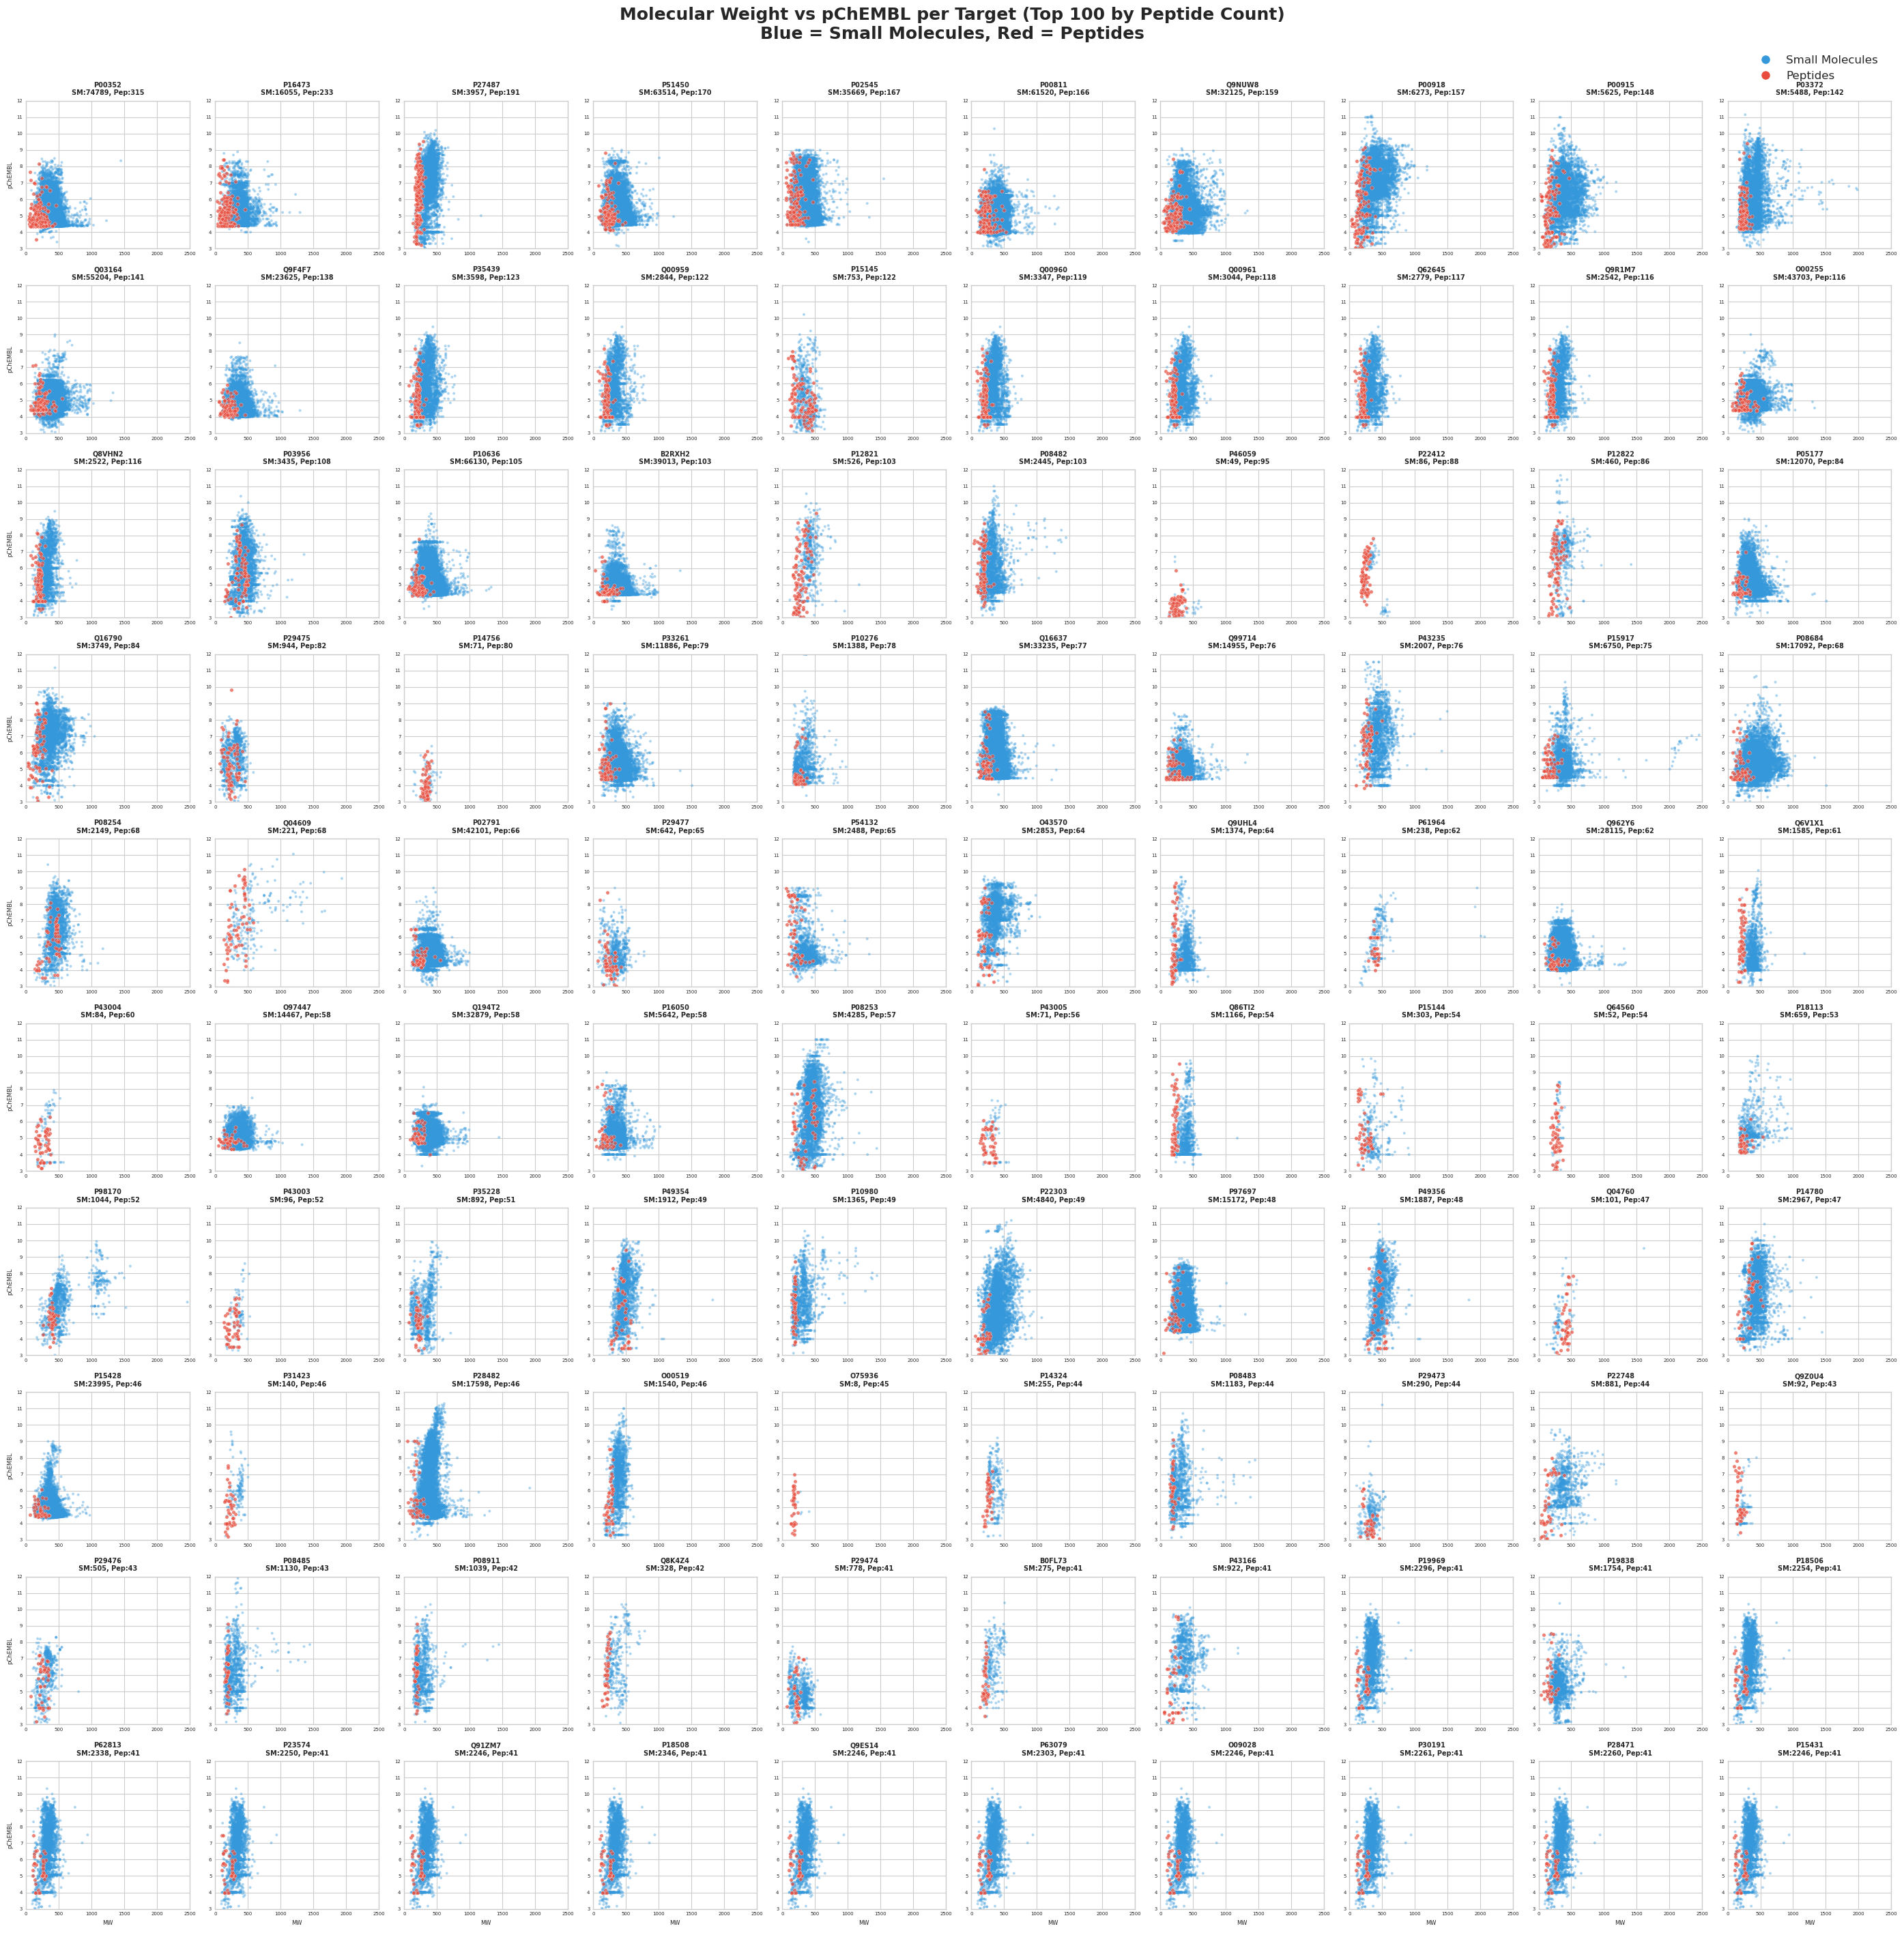


Saved scatter plot grid to /fsx/amira/papyrus_50.5_results/classified_full/mw_vs_pchembl_per_target_top100.png


In [14]:
# =============================================================================
# STEP 4g: MW vs pChEMBL Scatter Plots per Target (Top 100)
# =============================================================================

print("=" * 80)
print("STEP 4g: MW vs pChEMBL scatter plots per target (Top 100)")
print("=" * 80)

# First, merge MW from features_df into papyrus_df if not already there
if 'molecular_weight' not in papyrus_df.columns:
    print("Adding molecular_weight to main dataframe...")
    mw_map = features_df.set_index('SMILES')['molecular_weight'].to_dict()
    papyrus_df['molecular_weight'] = papyrus_df['SMILES'].map(mw_map)

# Get top 100 targets
top_100_targets = target_ranking.head(100)['accession'].tolist()

# Create 10x10 grid of scatter plots
n_cols = 10
n_rows = 10
fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 28))
axes = axes.flatten()

# Colors
colors = {'sm': '#3498db', 'can_peptide': '#e74c3c'}

print(f"\nCreating scatter plots for {len(top_100_targets)} targets...")

for idx, acc in enumerate(top_100_targets):
    ax = axes[idx]
    
    target_data = papyrus_df[papyrus_df['accession'] == acc].copy()
    target_data = target_data[target_data['predicted_mol_class'].isin(['sm', 'can_peptide'])]
    target_data = target_data.dropna(subset=['molecular_weight', 'pchembl_value_Mean'])
    
    if len(target_data) > 0:
        # Plot small molecules
        sm_data = target_data[target_data['predicted_mol_class'] == 'sm']
        pep_data = target_data[target_data['predicted_mol_class'] == 'can_peptide']
        
        if len(sm_data) > 0:
            ax.scatter(sm_data['molecular_weight'], sm_data['pchembl_value_Mean'], 
                      c='#3498db', alpha=0.4, s=8, label='SM', edgecolors='none')
        
        if len(pep_data) > 0:
            ax.scatter(pep_data['molecular_weight'], pep_data['pchembl_value_Mean'], 
                      c='#e74c3c', alpha=0.7, s=15, label='Pep', edgecolors='white', linewidths=0.3)
        
        # Set axis limits
        ax.set_xlim(0, 2500)
        ax.set_ylim(3, 12)
        
        # Get counts
        n_sm = len(sm_data)
        n_pep = len(pep_data)
        ax.set_title(f'{acc}\nSM:{n_sm}, Pep:{n_pep}', fontsize=7, fontweight='bold')
        
        ax.tick_params(axis='both', labelsize=5)
        
        # Only show axis labels on edges
        if idx % n_cols == 0:
            ax.set_ylabel('pChEMBL', fontsize=6)
        if idx >= (n_rows - 1) * n_cols:
            ax.set_xlabel('MW', fontsize=6)
    else:
        ax.set_visible(False)

# Add overall title and legend
fig.suptitle('Molecular Weight vs pChEMBL per Target (Top 100 by Peptide Count)\nBlue = Small Molecules, Red = Peptides', 
             fontsize=18, fontweight='bold', y=1.01)

# Add a shared legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=10, label='Small Molecules'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Peptides')
]
fig.legend(handles=handles, loc='upper right', fontsize=12, bbox_to_anchor=(0.99, 0.99))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/mw_vs_pchembl_per_target_top100.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved scatter plot grid to {OUTPUT_DIR}/mw_vs_pchembl_per_target_top100.png")


STEP 4h: MW vs pChEMBL scatter plot - Aggregated (Top 100 targets)

Data for top 100 targets:
  Small molecules: 916,922
  Peptides: 7,819


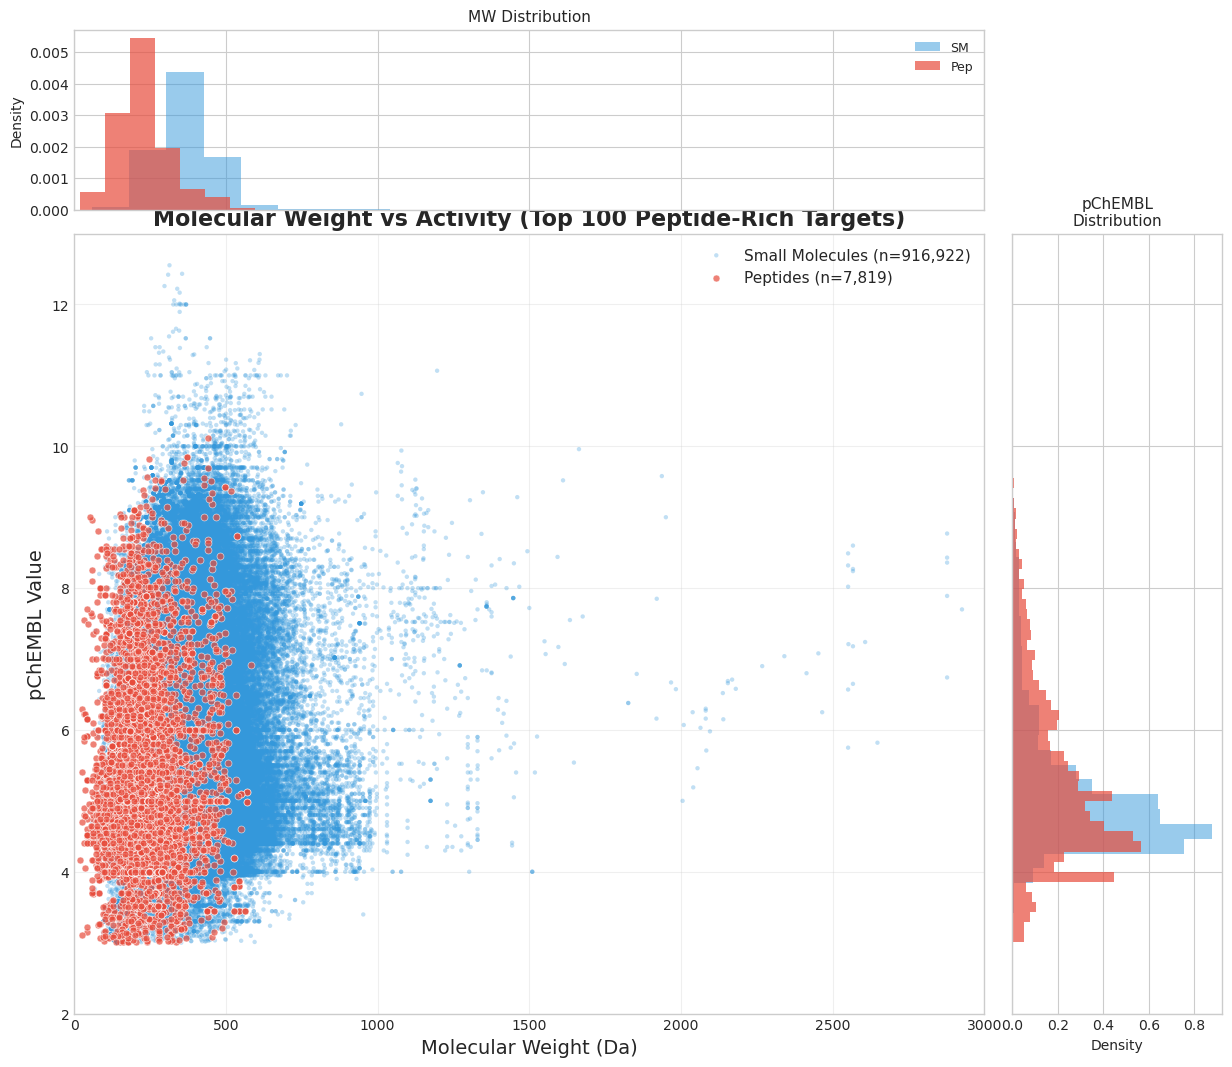


Saved aggregated plot to /fsx/amira/papyrus_50.5_results/classified_full/mw_vs_pchembl_aggregated_top100.png

STATISTICS - Top 100 Targets

Metric                         Small Molecules      Peptides            
----------------------------------------------------------------------
Count                          916,922            7,819
Mean MW                        365.2                228.0               
Median MW                      360.4                213.1               
Mean pChEMBL                   5.11                 5.27                
Median pChEMBL                 4.85                 5.00                


In [15]:
# =============================================================================
# STEP 4h: MW vs pChEMBL - Aggregated for Top 100 Targets
# =============================================================================

print("=" * 80)
print("STEP 4h: MW vs pChEMBL scatter plot - Aggregated (Top 100 targets)")
print("=" * 80)

# Get top 100 targets data
top_100_targets = target_ranking.head(100)['accession'].tolist()
top100_data = papyrus_df[papyrus_df['accession'].isin(top_100_targets)].copy()
top100_data = top100_data[top100_data['predicted_mol_class'].isin(['sm', 'can_peptide'])]
top100_data = top100_data.dropna(subset=['molecular_weight', 'pchembl_value_Mean'])

sm_data = top100_data[top100_data['predicted_mol_class'] == 'sm']
pep_data = top100_data[top100_data['predicted_mol_class'] == 'can_peptide']

print(f"\nData for top 100 targets:")
print(f"  Small molecules: {len(sm_data):,}")
print(f"  Peptides: {len(pep_data):,}")

# Create figure with main scatter + marginal histograms
fig = plt.figure(figsize=(14, 12))

# Main scatter plot
ax_main = fig.add_axes([0.1, 0.1, 0.65, 0.65])

# Plot SMs first (background)
ax_main.scatter(sm_data['molecular_weight'], sm_data['pchembl_value_Mean'], 
               c='#3498db', alpha=0.3, s=10, label=f'Small Molecules (n={len(sm_data):,})', 
               edgecolors='none', rasterized=True)

# Plot peptides on top (foreground)
ax_main.scatter(pep_data['molecular_weight'], pep_data['pchembl_value_Mean'], 
               c='#e74c3c', alpha=0.7, s=25, label=f'Peptides (n={len(pep_data):,})', 
               edgecolors='white', linewidths=0.5)

ax_main.set_xlabel('Molecular Weight (Da)', fontsize=14)
ax_main.set_ylabel('pChEMBL Value', fontsize=14)
ax_main.set_title('Molecular Weight vs Activity (Top 100 Peptide-Rich Targets)', fontsize=16, fontweight='bold')
ax_main.legend(loc='upper right', fontsize=11)
ax_main.set_xlim(0, 3000)
ax_main.set_ylim(2, 13)
ax_main.grid(True, alpha=0.3)

# Top histogram (MW distribution)
ax_top = fig.add_axes([0.1, 0.77, 0.65, 0.15], sharex=ax_main)
ax_top.hist(sm_data['molecular_weight'], bins=50, color='#3498db', alpha=0.5, label='SM', density=True)
ax_top.hist(pep_data['molecular_weight'], bins=50, color='#e74c3c', alpha=0.7, label='Pep', density=True)
ax_top.set_ylabel('Density', fontsize=10)
ax_top.set_title('MW Distribution', fontsize=11)
ax_top.tick_params(labelbottom=False)
ax_top.legend(fontsize=9)

# Right histogram (pChEMBL distribution)
ax_right = fig.add_axes([0.77, 0.1, 0.15, 0.65], sharey=ax_main)
ax_right.hist(sm_data['pchembl_value_Mean'], bins=50, color='#3498db', alpha=0.5, 
              orientation='horizontal', density=True)
ax_right.hist(pep_data['pchembl_value_Mean'], bins=50, color='#e74c3c', alpha=0.7, 
              orientation='horizontal', density=True)
ax_right.set_xlabel('Density', fontsize=10)
ax_right.set_title('pChEMBL\nDistribution', fontsize=11)
ax_right.tick_params(labelleft=False)

plt.savefig(f"{OUTPUT_DIR}/mw_vs_pchembl_aggregated_top100.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved aggregated plot to {OUTPUT_DIR}/mw_vs_pchembl_aggregated_top100.png")

# Print statistics
print(f"\n{'='*70}")
print("STATISTICS - Top 100 Targets")
print(f"{'='*70}")
print(f"\n{'Metric':<30} {'Small Molecules':<20} {'Peptides':<20}")
print("-" * 70)
print(f"{'Count':<30} {len(sm_data):,}{'':<11} {len(pep_data):,}")
print(f"{'Mean MW':<30} {sm_data['molecular_weight'].mean():<20.1f} {pep_data['molecular_weight'].mean():<20.1f}")
print(f"{'Median MW':<30} {sm_data['molecular_weight'].median():<20.1f} {pep_data['molecular_weight'].median():<20.1f}")
print(f"{'Mean pChEMBL':<30} {sm_data['pchembl_value_Mean'].mean():<20.2f} {pep_data['pchembl_value_Mean'].mean():<20.2f}")
print(f"{'Median pChEMBL':<30} {sm_data['pchembl_value_Mean'].median():<20.2f} {pep_data['pchembl_value_Mean'].median():<20.2f}")
